# ICR Data Analysis – Embedding-Derived Binding & Longitudinal Dynamics

This notebook performs two analyses using the **latest baseline projection model** (`best_baseline_projection_model.pt`):

1. **Analysis 1**: Association between embedding-derived binding score and clonal expansion
2. **Analysis 2**: Longitudinal dynamics of embedding-derived binding signal

The approach uses a kNN-based pseudo-binding score: for each ICR TCRβ clonotype, we find its nearest neighbours in the **reference embedding space** (training data with known binding labels) and compute the proportion of neighbours that are binders.

## Section 0: Setup — Imports, Paths, Model Definitions

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import spearmanr, pearsonr
import re
import gc
import os
import warnings
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

/home/natasha/miniconda3/envs/tcr-multimodal/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Device: cuda


In [2]:
# ── Paths ──
project_root    = Path("/home/natasha/multimodal_model")
checkpoints_dir = project_root / "models" / "checkpoints"
embeddings_dir  = project_root / "models" / "embeddings"
EMBED_ROOT      = embeddings_dir / "no_boltz"
DATA_DIR        = project_root / "data" / "ICR" / "data_2025_renamed"
figure_dir      = project_root / "models" / "figures" / "icr_analysis"
figure_dir.mkdir(parents=True, exist_ok=True)

print(f"Checkpoint dir: {checkpoints_dir}")
print(f"Embed root:     {EMBED_ROOT}")
print(f"ICR data dir:   {DATA_DIR}")
print(f"Figure dir:     {figure_dir}")

Checkpoint dir: /home/natasha/multimodal_model/models/checkpoints
Embed root:     /home/natasha/multimodal_model/models/embeddings/no_boltz
ICR data dir:   /home/natasha/multimodal_model/data/ICR/data_2025_renamed
Figure dir:     /home/natasha/multimodal_model/models/figures/icr_analysis


In [3]:
# ── Model class definitions ──

eps = 1e-8

class ESMProjectionHead(nn.Module):
    def __init__(self, D, rL, rD, d, L_max):
        super().__init__()
        self.D   = D
        self.rL  = rL
        self.rD  = rD
        self.d   = d
        self.L_max = L_max

        self.B_c = nn.Parameter(torch.empty(D, rD))
        nn.init.xavier_uniform_(self.B_c)
        self.A_c = nn.Parameter(torch.empty(L_max, rL))
        nn.init.xavier_uniform_(self.A_c)
        self.H_c = nn.Parameter(torch.empty(rL * rD, d))
        nn.init.xavier_uniform_(self.H_c)

        self.expander = nn.Sequential(
            nn.Linear(d, d),
            nn.BatchNorm1d(d),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(d, d),
        )

    def forward(self, emb, mask):
        device = emb.device
        B, L_pad, D = emb.shape
        assert D == self.D
        L_true = mask.sum(dim=1)
        z_list = []
        for b in range(B):
            Lb = int(L_true[b].item())
            if Lb == 0:
                z_list.append(torch.zeros(self.d, device=device))
                continue
            Xb = emb[b, :Lb, :] * mask[b, :Lb].unsqueeze(-1).float()
            Yb = Xb @ self.B_c
            A_pos = self.A_c[:Lb, :]
            Ub = A_pos.T @ Yb
            z_b = Ub.reshape(-1) @ self.H_c
            z_list.append(z_b)
        z = torch.stack(z_list, dim=0)
        z = self.expander(z)
        return z


class PMHCProjectionHead(nn.Module):
    def __init__(self, D, rL, rD, d, L_P_max, L_H_max, R_PH=0.7):
        super().__init__()
        d_P = int(round(R_PH * d))
        d_H = d - d_P
        self.d_P, self.d_H, self.D = d_P, d_H, D
        self.pep_encoder = ESMProjectionHead(D, rL, rD, d_P, L_P_max)
        self.hla_encoder = ESMProjectionHead(D, rL, rD, d_H, L_H_max)

    def forward(self, emb_P, mask_P, emb_H, mask_H):
        zP = self.pep_encoder(emb_P, mask_P)
        zH = self.hla_encoder(emb_H, mask_H)
        return torch.cat([zP, zH], dim=-1)


print("Model classes defined.")

Model classes defined.


## Section 1: Load ICR TCR Data

In [4]:
# ── Load and parse all TCRseq files ──

FNAME_RE = re.compile(
    r"^(?P<subject>ES\d+)_"
    r"(?P<timepoint>T\d+)_"
    r"(?P<tissue>[A-Za-z]+)_"
    r"(?P<library>C\d+)$"
)

def parse_sample_id(stem: str) -> dict:
    m = FNAME_RE.match(stem)
    if not m:
        return {"sample_id": stem, "subject_id": None, "timepoint": None,
                "tissue": None, "library": None, "fname_parse_ok": False}
    d = m.groupdict()
    return {"sample_id": stem, "subject_id": d["subject"],
            "timepoint": d["timepoint"], "tissue": d["tissue"],
            "library": d["library"], "fname_parse_ok": True}

dfs = []
for fp in sorted(DATA_DIR.glob("*.tsv.gz")):
    stem = fp.name.replace(".tsv.gz", "")
    meta = parse_sample_id(stem)
    tmp = pd.read_csv(fp, sep="\t", compression="gzip")
    for k, v in meta.items():
        tmp[k] = v
    dfs.append(tmp)

full_df = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(full_df)} rows from {len(dfs)} files")
print(f"Subjects: {full_df['subject_id'].nunique()}")
print(f"Samples:  {full_df['sample_id'].nunique()}")

Loaded 191764 rows from 152 files
Subjects: 15
Samples:  152


In [5]:
# ── Coerce productive column and filter ──

def coerce_bool(s: pd.Series) -> pd.Series:
    if s.dtype == "bool":
        return s.astype("boolean")
    x = s.astype(str).str.strip().str.lower()
    out = pd.Series(pd.NA, index=s.index, dtype="boolean")
    out[x.isin({"true", "t", "1", "yes", "y", "1.0"})] = True
    out[x.isin({"false", "f", "0", "no", "n", "0.0"})] = False
    return out

if "productive" in full_df.columns:
    full_df["productive"] = coerce_bool(full_df["productive"])

# Filter: productive, valid AA CDR3β
df = full_df.copy()
if "productive" in df.columns:
    df = df[df["productive"] == True].copy()
df = df[df["sequence_aa"].notna()].copy()
df["sequence_aa"] = df["sequence_aa"].astype(str).str.strip()
aa_re = r"^[ACDEFGHIKLMNPQRSTVWY]+$"
df = df[df["sequence_aa"].str.fullmatch(aa_re)].copy()

print(f"After filtering: {len(df)} rows, {df['sequence_aa'].nunique()} unique CDR3β")

After filtering: 156585 rows, 133936 unique CDR3β


In [6]:
# ── Build clonotype tables ──

# Sample-level: expansion per sample
clono_sample = (
    df.groupby(["sample_id", "sequence_aa"], as_index=False)
      .agg(
          total_count=("duplicate_count", "sum"),
          n_rows=("duplicate_count", "size"),
          v_mode=("v_call", lambda x: x.value_counts().index[0] if x.notna().any() else None),
          j_mode=("j_call", lambda x: x.value_counts().index[0] if x.notna().any() else None),
      )
)
clono_sample["log_total_count"] = np.log1p(clono_sample["total_count"])

# Merge back sample metadata
sample_meta = df[["sample_id", "subject_id", "timepoint", "tissue"]].drop_duplicates()
clono_sample = clono_sample.merge(sample_meta, on="sample_id", how="left")

# Global-level: total abundance across all samples
clono_global = (
    clono_sample.groupby("sequence_aa", as_index=False)
      .agg(
          total_count_all=("total_count", "sum"),
          n_samples=("sample_id", "nunique"),
          n_rows_all=("n_rows", "sum"),
      )
)
clono_global["log_total_count_all"] = np.log1p(clono_global["total_count_all"])

print(f"Unique clonotypes (global): {len(clono_global)}")
print(f"Unique clonotype-sample pairs: {len(clono_sample)}")
print(f"Median samples per clonotype: {clono_global['n_samples'].median()}")

Unique clonotypes (global): 133936
Unique clonotype-sample pairs: 153254
Median samples per clonotype: 1.0


In [7]:
# ── Step 0: Select subjects with richer longitudinal sampling ──

SELECTED_SUBJECTS = ["ES02", "ES10", "ES14", "ES15"]

clono_sample_sub = clono_sample[
    clono_sample["subject_id"].isin(SELECTED_SUBJECTS)
].copy()

clono_global_sub = (
    clono_sample_sub.groupby("sequence_aa", as_index=False)
      .agg(
          total_count_all=("total_count", "sum"),
          n_samples=("sample_id", "nunique"),
          n_rows_all=("n_rows", "sum"),
      )
)

clono_global_sub["log_total_count_all"] = np.log1p(clono_global_sub["total_count_all"])

print(f"Selected subjects: {SELECTED_SUBJECTS}")
print(f"Clonotype-sample rows: {len(clono_sample_sub):,}")
print(f"Unique clonotypes to embed: {len(clono_global_sub):,}")
print(f"Median samples per clonotype: {clono_global_sub['n_samples'].median()}")
print(clono_sample_sub[['subject_id', 'sample_id', 'timepoint', 'tissue']].drop_duplicates().sort_values(['subject_id', 'timepoint']).head(20))

Selected subjects: ['ES02', 'ES10', 'ES14', 'ES15']
Clonotype-sample rows: 28,779
Unique clonotypes to embed: 25,777
Median samples per clonotype: 1.0
      subject_id       sample_id timepoint tissue
888         ES02   ES02_T1_Bo_C3        T1     Bo
2118        ES02   ES02_T1_Bo_C4        T1     Bo
2694        ES02   ES02_T1_Bo_C5        T1     Bo
4602        ES02   ES02_T1_Bo_C6        T1     Bo
32195       ES02   ES02_T2_Lu_C1        T2     Lu
32331       ES02   ES02_T3_Lu_C8        T3     Lu
32511       ES02   ES02_T4_Li_C5        T4     Li
46276       ES10   ES10_T1_Bo_C1        T1     Bo
46648       ES10   ES10_T1_Bo_C2        T1     Bo
46786       ES10   ES10_T1_Bo_C3        T1     Bo
47546       ES10   ES10_T4_Li_C2        T4     Li
47714       ES10   ES10_T5_Lu_C1        T5     Lu
47792       ES10   ES10_T5_Lu_C2        T5     Lu
47998       ES10   ES10_T6_Lu_C1        T6     Lu
48192       ES10  ES10_T6_Lu_C19        T6     Lu
48304       ES10   ES10_T6_Lu_C4        T6     Lu

In [8]:
# # ── Subset: expanded clonotypes only ──
# # Embedding ~130K clonotypes is expensive and most singletons are noise.
# # We keep clonotypes with ≥3 total reads (likely antigen-experienced)
# # plus a random background sample of low-count clonotypes for comparison.

# MIN_COUNT = 3  # minimum total reads to count as "expanded"
# N_BACKGROUND = 2000  # random singletons for baseline comparison

# # remove this filtering and filter on patients instead - ES2 and ES10 have the longest time points

# expanded = clono_global[clono_global["total_count_all"] >= MIN_COUNT].copy()
# singletons = clono_global[clono_global["total_count_all"] < MIN_COUNT]

# rng = np.random.default_rng(42)
# bg_idx = rng.choice(len(singletons), size=min(N_BACKGROUND, len(singletons)), replace=False)
# background = singletons.iloc[bg_idx].copy()

# clono_embed = pd.concat([expanded, background], ignore_index=True)
# clono_embed["is_expanded"] = clono_embed["total_count_all"] >= MIN_COUNT

# print(f"Full clonotype universe:  {len(clono_global):,}")
# print(f"Expanded (≥{MIN_COUNT} reads):     {len(expanded):,}")
# print(f"Background sample:       {len(background):,}")
# print(f"Embedding subset:        {len(clono_embed):,}")
# print(f"\nThis reduces embedding cost by ~{(1 - len(clono_embed)/len(clono_global))*100:.0f}%")



In [9]:
# ── Step 1: Set embedding input table ──

clono_embed = clono_global_sub.copy()
embed_sequences = clono_embed["sequence_aa"].astype(str).tolist()

print(f"Embedding {len(embed_sequences):,} unique clonotypes")

Embedding 25,777 unique clonotypes


## Section 2: Load Latest Model & Build Reference Embedding Set

In [10]:
# ── Load the training/val data to build the reference set ──

class ShardedBatchTripletDataset(Dataset):
    def __init__(self, shards_dir):
        self.shards_dir = Path(shards_dir)
        self.shard_paths = sorted(self.shards_dir.glob("shard_*.pt"))
        assert self.shard_paths, f"No shard_*.pt files in {self.shards_dir}"
        self.index = []
        for sp in self.shard_paths:
            shard = torch.load(sp, map_location="cpu")
            for j in range(len(shard)):
                self.index.append((sp, j))
        self._cache_path = None
        self._cache_data = None

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sp, j = self.index[idx]
        if self._cache_path != sp:
            self._cache_data = torch.load(sp, map_location="cpu")
            self._cache_path = sp
        return self._cache_data[j]


train_dataset = ShardedBatchTripletDataset(EMBED_ROOT / "train")
val_dataset   = ShardedBatchTripletDataset(EMBED_ROOT / "val")

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=False,
                          num_workers=0, collate_fn=lambda x: x[0])
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False,
                        num_workers=0, collate_fn=lambda x: x[0])

# Get dimensions from a sample
sample = train_dataset[0]
L_T_max = sample["emb_T"].shape[1]
L_P_max = sample["emb_P"].shape[1]
L_H_max = sample["emb_H"].shape[1]
D       = sample["emb_T"].shape[2]

print(f"D={D}, L_T_max={L_T_max}, L_P_max={L_P_max}, L_H_max={L_H_max}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

D=960, L_T_max=249, L_P_max=26, L_H_max=368
Train batches: 3895, Val batches: 493


In [11]:
# ── Load best checkpoint ──

ckpt_path = checkpoints_dir / "best_baseline_projection_model.pt"
checkpoint = torch.load(ckpt_path, map_location="cpu")

cfg = checkpoint["best_config"]
best_threshold = checkpoint["best_threshold"]

print("Best config:", cfg)
print(f"Best threshold: {best_threshold:.4f}")
print(f"Best epoch: {checkpoint['best_epoch']}")
print(f"Best val AUROC: {checkpoint['best_val_metrics']['auroc']:.4f}")
print(f"Best val F1:    {checkpoint['best_val_metrics']['f1']:.4f}")

# Instantiate and load projection heads
rL, rD, d = cfg["rL"], cfg["rD"], cfg["d"]
R_PH = cfg.get("R_PH", 0.7)

tcr_projection = ESMProjectionHead(D, rL, rD, d, L_max=L_T_max).to(device)
pmhc_projection = PMHCProjectionHead(D, rL, rD, d,
                                      L_P_max=L_P_max, L_H_max=L_H_max,
                                      R_PH=R_PH).to(device)

tcr_projection.load_state_dict(checkpoint["tcr_projection_state_dict"])
pmhc_projection.load_state_dict(checkpoint["pmhc_projection_state_dict"])
tcr_projection.eval()
pmhc_projection.eval()

print("\nProjection heads loaded and set to eval mode.")

Best config: {'rL': 8, 'rD': 16, 'd': 128, 'R_PH': 0.7, 'alpha': 25.0, 'beta': 25.0, 'delta': 1.0, 'gamma_var': 1.0, 'lr_tcr': 0.0001, 'lr_pmhc': 0.0001, 'weight_decay': 0.01, 'num_epochs': 20, 'patience': 5, 'loss_type': 'vicreg_mse'}
Best threshold: -1.8508
Best epoch: 14
Best val AUROC: 0.7260
Best val F1:    0.6863

Projection heads loaded and set to eval mode.


In [12]:
# ── Collect reference embeddings (zT + binding labels) from train+val ──

@torch.no_grad()
def collect_tcr_embeddings_and_labels(loader, tcr_proj, device):
    """Extract zT embeddings and binding flags from a sharded loader."""
    tcr_proj.eval()
    all_zT, all_labels = [], []
    for batch in loader:
        emb_T  = batch["emb_T"].to(device)
        mask_T = batch["mask_T"].to(device)
        zT = tcr_proj(emb_T, mask_T)
        all_zT.append(zT.cpu().numpy())

        labels = batch["binding_flag"]
        if torch.is_tensor(labels):
            labels = labels.cpu().numpy()
        else:
            labels = np.array(labels)
        all_labels.append(labels)
    return np.concatenate(all_zT), np.concatenate(all_labels).astype(int)

print("Collecting reference embeddings from training set...")
ref_zT_train, ref_labels_train = collect_tcr_embeddings_and_labels(
    train_loader, tcr_projection, device
)
print(f"  Train: {ref_zT_train.shape[0]} samples, {ref_labels_train.sum()} binders")

print("Collecting reference embeddings from validation set...")
ref_zT_val, ref_labels_val = collect_tcr_embeddings_and_labels(
    val_loader, tcr_projection, device
)
print(f"  Val: {ref_zT_val.shape[0]} samples, {ref_labels_val.sum()} binders")

# Combine into a single reference set
ref_zT     = np.concatenate([ref_zT_train, ref_zT_val], axis=0)
ref_labels = np.concatenate([ref_labels_train, ref_labels_val], axis=0)

print(f"\nReference set: {ref_zT.shape[0]} TCR embeddings, "
      f"{ref_labels.sum()} binders ({ref_labels.mean()*100:.1f}%)")
print(f"Embedding dim: {ref_zT.shape[1]}")

  Train: 31154 samples, 31154 binders
  Val: 3944 samples, 1944 binders

Reference set: 35098 TCR embeddings, 33098 binders (94.3%)
Embedding dim: 128


In [13]:
# ── Build kNN index on the reference set ──

# L2-normalise for cosine distance
ref_zT_norm = ref_zT / (np.linalg.norm(ref_zT, axis=1, keepdims=True) + 1e-12)

K_NEIGHBOURS = 30  # number of neighbours for pseudo-binding score

knn = NearestNeighbors(n_neighbors=K_NEIGHBOURS, metric="cosine", n_jobs=-1)
knn.fit(ref_zT_norm)

print(f"kNN index built: k={K_NEIGHBOURS}, metric=cosine, n_ref={ref_zT_norm.shape[0]}")

kNN index built: k=30, metric=cosine, n_ref=35098


## Section 3: Embed ICR TCRβ Sequences Through the Projection Head

We embed the subset of expanded clonotypes belonging to 4 patients
using the full pipeline: ESMC (frozen) → token embeddings → trained projection head → zT ∈ ℝᵈ.



In [14]:
# ── Load ESMC encoder ──

from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein

esmc_model = ESMC.from_pretrained("esmc_300m").to(device).eval()
pad_id = esmc_model.tokenizer.pad_token_id
print(f"ESMC loaded. pad_id={pad_id}")

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

ESMC loaded. pad_id=1


In [15]:
# ── Embedding function: ESMC → projection head → zT ──

def pad_batch_1d(token_seqs, pad_id: int, device):
    lengths = torch.tensor([t.numel() for t in token_seqs], device=device)
    max_len = int(lengths.max().item())
    out = torch.full((len(token_seqs), max_len), pad_id,
                     dtype=token_seqs[0].dtype, device=device)
    for i, t in enumerate(token_seqs):
        out[i, :t.numel()] = t
    attn = (out != pad_id)
    return out, attn, lengths


@torch.no_grad()
def embed_icr_clonotypes(sequences, esmc, projection, device,
                         batch_size=8, max_length=None):
    """
    Full pipeline: raw AA sequences → ESMC tokens → ESMC embeddings
    → projection head → zT (d-dim latent).
    
    If max_length is set, sequences longer than this are truncated
    (to stay within projection head's L_max).
    """
    esmc.eval()
    projection.eval()
    
    all_zT = []
    skipped = 0
    
    for i in range(0, len(sequences), batch_size):
        batch_seqs = sequences[i:i+batch_size]
        
        # Encode sequences to tokens via ESMC
        encoded = [esmc.encode(ESMProtein(sequence=s)) for s in batch_seqs]
        token_seqs = [pt.sequence.to(device) for pt in encoded]
        
        # Truncate if needed (projection head has fixed L_max)
        if max_length is not None:
            token_seqs = [t[:max_length] for t in token_seqs]
        
        toks, attn, lengths = pad_batch_1d(token_seqs, pad_id, device)
        
        # Check length constraint
        max_Lb = int(attn.sum(dim=1).max().item())
        if max_Lb > projection.L_max:
            skipped += len(batch_seqs)
            continue
        
        # ESMC forward → token embeddings
        out = esmc(sequence_tokens=toks)
        emb_T = out.embeddings  # (B, L, D)
        
        # Projection head forward → zT
        zT = projection(emb_T, attn)
        all_zT.append(zT.cpu().numpy())
        
        if (i // batch_size) % 200 == 0:
            print(f"  Embedded {i+len(batch_seqs)}/{len(sequences)}...")
        
        # Memory management
        del toks, attn, out, emb_T, zT
        if torch.cuda.is_available() and (i % 400 == 0):
            torch.cuda.empty_cache()
    
    if skipped > 0:
        print(f"  WARNING: skipped {skipped} sequences exceeding L_max={projection.L_max}")
    
    return np.concatenate(all_zT, axis=0)

print("Embedding function defined.")

Embedding function defined.


In [16]:
# ── Step 2: Embed selected clonotypes (cached) ──

subset_tag = "_".join(SELECTED_SUBJECTS)
icr_zT_cache = project_root / "embeddings" / f"icr_clonotype_zT_{subset_tag}.npy"
icr_seq_cache = project_root / "embeddings" / f"icr_clonotype_seqs_{subset_tag}.npy"

icr_zT = None

if icr_zT_cache.exists() and icr_seq_cache.exists():
    cached_seqs = np.load(icr_seq_cache, allow_pickle=True)
    if len(cached_seqs) == len(embed_sequences) and np.all(cached_seqs == np.array(embed_sequences, dtype=object)):
        print("Loading cached subset embeddings...")
        icr_zT = np.load(icr_zT_cache)
        print(f"Loaded cached embeddings: {icr_zT.shape}")
    else:
        print("Cache mismatch; re-embedding.")

if icr_zT is None:
    print(f"Embedding {len(embed_sequences):,} clonotypes...")
    icr_zT = embed_icr_clonotypes(
        embed_sequences,
        esmc_model,
        tcr_projection,
        device,
        batch_size=8,
        max_length=L_T_max,
    )
    icr_zT_cache.parent.mkdir(parents=True, exist_ok=True)
    np.save(icr_zT_cache, icr_zT)
    np.save(icr_seq_cache, np.array(embed_sequences, dtype=object))
    print(f"Saved cache: {icr_zT.shape}")

print("Final embedding shape:", icr_zT.shape)

Loading cached subset embeddings...
Loaded cached embeddings: (25777, 128)
Final embedding shape: (25777, 128)


In [17]:
# # ── Embed the subset of ICR clonotypes ──
# # Only embed clono_embed (expanded + background), not the full 130K.
# # Results are cached to disk.

# icr_zT_cache = project_root / "embeddings" / "icr_clonotype_zT_subset.npy"
# icr_seq_cache = project_root / "embeddings" / "icr_clonotype_seqs_subset.npy"

# embed_sequences = clono_embed["sequence_aa"].tolist()

# if icr_zT_cache.exists() and icr_seq_cache.exists():
#     cached_seqs = np.load(icr_seq_cache, allow_pickle=True)
#     if len(cached_seqs) == len(embed_sequences):
#         print("Loading cached ICR embeddings...")
#         icr_zT = np.load(icr_zT_cache)
#         print(f"Loaded {icr_zT.shape[0]} embeddings from cache.")
#     else:
#         print(f"Cache size mismatch ({len(cached_seqs)} vs {len(embed_sequences)}). Re-embedding.")
#         icr_zT = None
# else:
#     icr_zT = None

# if icr_zT is None:
#     print(f"Embedding {len(embed_sequences)} clonotypes (subset)...")
#     icr_zT = embed_icr_clonotypes(
#         embed_sequences, esmc_model, tcr_projection, device,
#         batch_size=8, max_length=L_T_max
#     )
#     icr_zT_cache.parent.mkdir(parents=True, exist_ok=True)
#     np.save(icr_zT_cache, icr_zT)
#     np.save(icr_seq_cache, np.array(embed_sequences, dtype=object))
#     print(f"Saved cache: {icr_zT.shape}")

# print(f"ICR subset embeddings: {icr_zT.shape}")

In [18]:
# ── Step 3: Attach embeddings + dominant subject metadata ──

clono_embed = clono_embed.reset_index(drop=True).copy()
clono_embed["z_idx"] = np.arange(len(clono_embed))

# attach embedding vectors
clono_embed["zT"] = list(icr_zT)

# dominant subject / timepoint metadata for display only
seq_subject_meta = (
    clono_sample_sub.groupby(["sequence_aa", "subject_id"], as_index=False)
    .agg(total_count_subject=("total_count", "sum"))
    .sort_values(["sequence_aa", "total_count_subject"], ascending=[True, False])
    .drop_duplicates("sequence_aa")
    .rename(columns={"subject_id": "dominant_subject"})
)

clono_embed = clono_embed.merge(seq_subject_meta[["sequence_aa", "dominant_subject"]], on="sequence_aa", how="left")

print(clono_embed.head())

                                         sequence_aa  total_count_all  \
0  AAGVIQSPRHLIKEKRETATLKCYPIPRHDTVYWYQQGPGQDPQFL...                3   
1  AAGVIQSPRHLIKEKRETATLKCYPIPRHDTVYWYQQGPGQDPQFL...                2   
2  AAGVIQSPRHLIKEKRETATLKCYPIPRHDTVYWYQQGPGQDPQFL...                1   
3  AAGVIQSPRHLIKEKRETATLKCYPIPRHDTVYWYQQGPGQDPQFL...                2   
4  AAGVIQSPRHLIKEKRETATLKCYPIPRHDTVYWYQQGPGQDPQFL...                1   

   n_samples  n_rows_all  log_total_count_all  z_idx  \
0          1           1             1.386294      0   
1          1           1             1.098612      1   
2          1           1             0.693147      2   
3          1           1             1.098612      3   
4          1           1             0.693147      4   

                                                  zT dominant_subject  
0  [-0.13884032, 0.101096086, 0.1059788, 0.065109...             ES15  
1  [-0.09596692, 0.056898896, 0.055288, 0.0338774...             ES02  
2  [0.14

In [19]:
# ── Step 4: Expansion bins for intuitive plots ──

def expansion_bin(x):
    if x == 1:
        return "1"
    elif x == 2:
        return "2"
    elif 3 <= x <= 5:
        return "3–5"
    elif 6 <= x <= 10:
        return "6–10"
    else:
        return ">10"

clono_embed["expansion_bin"] = clono_embed["total_count_all"].apply(expansion_bin)

bin_order = ["1", "2", "3–5", "6–10", ">10"]
clono_embed["expansion_bin"] = pd.Categorical(clono_embed["expansion_bin"], categories=bin_order, ordered=True)

print(clono_embed["expansion_bin"].value_counts(dropna=False).sort_index())

expansion_bin
1       12546
2        4882
3–5      4905
6–10     2020
>10      1424
Name: count, dtype: int64


In [20]:
# ── Step 5: 2D projection of clonotype latent space ──

from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt

X = np.vstack(clono_embed["zT"].values)

# modest PCA first for denoising
X_pca = PCA(n_components=min(30, X.shape[1]), random_state=42).fit_transform(X)

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.15,
    metric="euclidean",
    random_state=42,
)
Y = reducer.fit_transform(X_pca)

clono_embed["umap1"] = Y[:, 0]
clono_embed["umap2"] = Y[:, 1]

print(clono_embed[["umap1", "umap2"]].head())

      umap1      umap2
0 -1.240246   6.818174
1 -1.207254   7.459201
2  0.790213  10.868322
3  1.050765  10.100980
4 -1.523409  11.308915


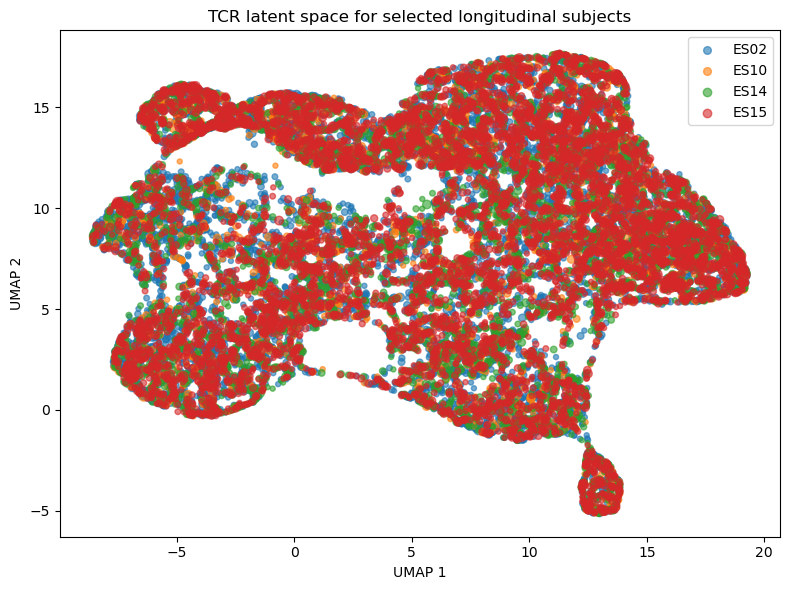

In [21]:
# ── Plot 1: Latent space by patient, size ~ expansion ──

plt.figure(figsize=(8, 6))

for subj in SELECTED_SUBJECTS:
    sub = clono_embed[clono_embed["dominant_subject"] == subj]
    if len(sub) == 0:
        continue
    plt.scatter(
        sub["umap1"],
        sub["umap2"],
        s=8 + 8 * sub["log_total_count_all"],
        alpha=0.6,
        label=subj,
    )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("TCR latent space for selected longitudinal subjects")
plt.legend()
plt.tight_layout()
plt.savefig(figure_dir / "latent_space_selected_subjects_by_patient.png", dpi=200, bbox_inches="tight")
plt.show()

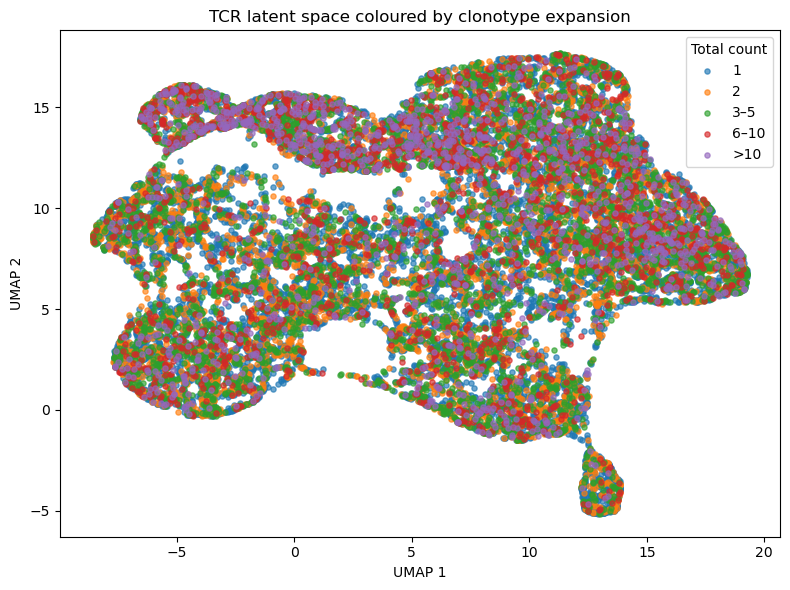

In [22]:
# ── Plot 2: Latent space coloured by expansion bin ──

plt.figure(figsize=(8, 6))

for b in bin_order:
    sub = clono_embed[clono_embed["expansion_bin"] == b]
    if len(sub) == 0:
        continue
    plt.scatter(
        sub["umap1"],
        sub["umap2"],
        s=14,
        alpha=0.65,
        label=b,
    )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("TCR latent space coloured by clonotype expansion")
plt.legend(title="Total count")
plt.tight_layout()
plt.savefig(figure_dir / "latent_space_selected_subjects_by_expansion_bin.png", dpi=200, bbox_inches="tight")
plt.show()

In [23]:
# ── Step 6: Local density analysis via kNN distance ──

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

X_norm = normalize(X, norm="l2")

k = 15
nn = NearestNeighbors(n_neighbors=k + 1, metric="cosine", n_jobs=-1)
nn.fit(X_norm)

distances, indices = nn.kneighbors(X_norm, return_distance=True)

# ignore self-neighbour at position 0
knn_mean_dist = distances[:, 1:].mean(axis=1)
knn_median_dist = np.median(distances[:, 1:], axis=1)

clono_embed["knn_mean_dist"] = knn_mean_dist
clono_embed["knn_median_dist"] = knn_median_dist

# distance to global centroid
centroid = X_norm.mean(axis=0)
centroid = centroid / np.linalg.norm(centroid)
clono_embed["dist_to_centroid"] = 1 - (X_norm @ centroid)

clono_embed[["knn_mean_dist", "knn_median_dist", "dist_to_centroid"]].describe()

,knn_mean_dist,knn_median_dist,dist_to_centroid
count,25777.000000,25777.000000,25777.000000
mean,0.000271,0.000285,0.051193
std,0.002446,0.002665,0.087214
min,0.000009,0.000009,0.000248
25%,0.000038,0.000039,0.008637
50%,0.000075,0.000078,0.021731
75%,0.000212,0.000219,0.049943
max,0.208810,0.228962,1.133740


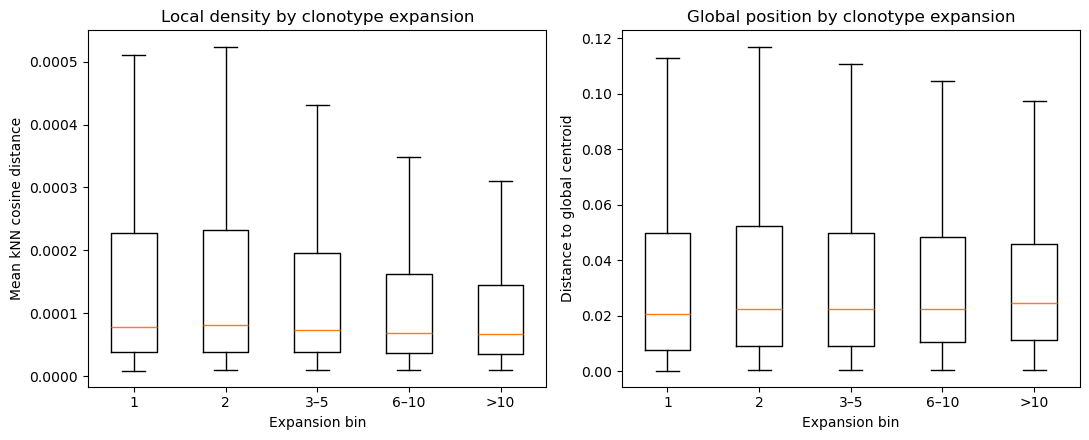

In [24]:
# ── Plot 3: kNN distance by expansion bin ──

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

data1 = [clono_embed.loc[clono_embed["expansion_bin"] == b, "knn_mean_dist"].dropna().values for b in bin_order]
axes[0].boxplot(data1, labels=bin_order, showfliers=False)
axes[0].set_xlabel("Expansion bin")
axes[0].set_ylabel("Mean kNN cosine distance")
axes[0].set_title("Local density by clonotype expansion")

data2 = [clono_embed.loc[clono_embed["expansion_bin"] == b, "dist_to_centroid"].dropna().values for b in bin_order]
axes[1].boxplot(data2, labels=bin_order, showfliers=False)
axes[1].set_xlabel("Expansion bin")
axes[1].set_ylabel("Distance to global centroid")
axes[1].set_title("Global position by clonotype expansion")

plt.tight_layout()
plt.savefig(figure_dir / "expansion_vs_latent_geometry.png", dpi=200, bbox_inches="tight")
plt.show()

In [25]:
# ── Step 7: Numeric expansion summaries ──

expansion_summary = (
    clono_embed.groupby("expansion_bin", as_index=False)
    .agg(
        n_clonotypes=("sequence_aa", "size"),
        mean_log_count=("log_total_count_all", "mean"),
        mean_knn_dist=("knn_mean_dist", "mean"),
        median_knn_dist=("knn_mean_dist", "median"),
        mean_centroid_dist=("dist_to_centroid", "mean"),
        median_centroid_dist=("dist_to_centroid", "median"),
    )
)

print(expansion_summary.to_string(index=False))

expansion_bin  n_clonotypes  mean_log_count  mean_knn_dist  median_knn_dist  mean_centroid_dist  median_centroid_dist
            1         12546        0.693147       0.000281         0.000078            0.051347              0.020708
            2          4882        1.098612       0.000318         0.000081            0.055044              0.022566
          3–5          4905        1.532583       0.000232         0.000073            0.049622              0.022475
         6–10          2020        2.135747       0.000278         0.000068            0.047178              0.022440
          >10          1424        2.974776       0.000152         0.000066            0.047741              0.024612


In [26]:
# ── Step 8: Propagate embeddings back to sample-level table ──

z_map = clono_embed.set_index("sequence_aa")["zT"].to_dict()
global_count_map = clono_embed.set_index("sequence_aa")["total_count_all"].to_dict()
global_bin_map = clono_embed.set_index("sequence_aa")["expansion_bin"].to_dict()

clono_sample_sub = clono_sample_sub.copy()
clono_sample_sub["zT"] = clono_sample_sub["sequence_aa"].map(z_map)
clono_sample_sub["global_total_count_all"] = clono_sample_sub["sequence_aa"].map(global_count_map)
clono_sample_sub["global_expansion_bin"] = clono_sample_sub["sequence_aa"].map(global_bin_map)

cs_embed = clono_sample_sub.dropna(subset=["zT"]).copy()
print(f"Sample-level rows with embeddings: {len(cs_embed):,} / {len(clono_sample_sub):,}")
print("Subjects in cs_embed:", sorted(cs_embed["subject_id"].dropna().unique()))

Sample-level rows with embeddings: 28,779 / 28,779
Subjects in cs_embed: ['ES02', 'ES10', 'ES14', 'ES15']


In [27]:
# ── Step 9: Compute sample-level repertoire centroids ──

def compute_centroid(arrs, weights=None):
    Xs = np.vstack(arrs)
    if weights is None:
        c = Xs.mean(axis=0)
    else:
        w = np.asarray(weights, dtype=float)
        c = np.average(Xs, axis=0, weights=w)
    return c

sample_centroids = []

for (sample_id, subject_id, timepoint, tissue), g in cs_embed.groupby(["sample_id", "subject_id", "timepoint", "tissue"]):
    arrs = g["zT"].tolist()
    counts = g["total_count"].astype(float).values

    c_unw = compute_centroid(arrs, weights=None)
    c_w   = compute_centroid(arrs, weights=counts)

    sample_centroids.append({
        "sample_id": sample_id,
        "subject_id": subject_id,
        "timepoint": timepoint,
        "tissue": tissue,
        "n_clonotypes": len(g),
        "total_reads": g["total_count"].sum(),
        "mean_log_count": g["log_total_count"].mean(),
        "centroid_unweighted": c_unw,
        "centroid_weighted": c_w,
        "centroid_shift_within_sample": np.linalg.norm(c_w - c_unw),
    })

sample_summary = pd.DataFrame(sample_centroids)

sample_summary["tp_num"] = (
    sample_summary["timepoint"].astype(str).str.extract(r"(\d+)")[0].astype(float)
)

print(sample_summary.head())

       sample_id subject_id timepoint tissue  n_clonotypes  total_reads  \
0  ES02_T1_Bo_C3       ES02        T1     Bo          1230         4728   
1  ES02_T1_Bo_C4       ES02        T1     Bo           576         1227   
2  ES02_T1_Bo_C5       ES02        T1     Bo          1908         5081   
3  ES02_T1_Bo_C6       ES02        T1     Bo          8464        13926   
4  ES02_T2_Lu_C1       ES02        T2     Lu           136         1164   

   mean_log_count                                centroid_unweighted  \
0        1.329243  [0.038589902, -0.056910347, -0.045193966, -0.1...   
1        0.978218  [0.06507825, -0.08086869, -0.07108821, -0.1360...   
2        1.104767  [0.033554357, -0.051331818, -0.03943482, -0.10...   
3        0.905522  [0.030016256, -0.04763457, -0.033961397, -0.10...   
4        1.755752  [0.036326032, -0.053468283, -0.041817546, -0.1...   

                                   centroid_weighted  \
0  [0.09669434918522482, -0.11383052259272314, -0...   
1  [

In [28]:
# ── Step 10: 2D projection of sample repertoire centroids ──

C_unw = np.vstack(sample_summary["centroid_unweighted"].values)
C_w   = np.vstack(sample_summary["centroid_weighted"].values)

C_all = np.vstack([C_unw, C_w])
C_pca = PCA(n_components=min(10, C_all.shape[1]), random_state=42).fit_transform(C_all)

centroid_umap = umap.UMAP(
    n_neighbors=min(10, len(C_all) - 1),
    min_dist=0.2,
    metric="euclidean",
    random_state=42,
).fit_transform(C_pca)

sample_summary["umap1_unw"] = centroid_umap[:len(sample_summary), 0]
sample_summary["umap2_unw"] = centroid_umap[:len(sample_summary), 1]
sample_summary["umap1_w"]   = centroid_umap[len(sample_summary):, 0]
sample_summary["umap2_w"]   = centroid_umap[len(sample_summary):, 1]

print(sample_summary[["sample_id", "subject_id", "timepoint", "umap1_unw", "umap2_unw"]].head())

       sample_id subject_id timepoint  umap1_unw  umap2_unw
0  ES02_T1_Bo_C3       ES02        T1   7.769056   0.435440
1  ES02_T1_Bo_C4       ES02        T1   6.429553   0.980368
2  ES02_T1_Bo_C5       ES02        T1   6.554602  -0.242150
3  ES02_T1_Bo_C6       ES02        T1   7.093544  -0.306909
4  ES02_T2_Lu_C1       ES02        T2   6.490312  -0.760667


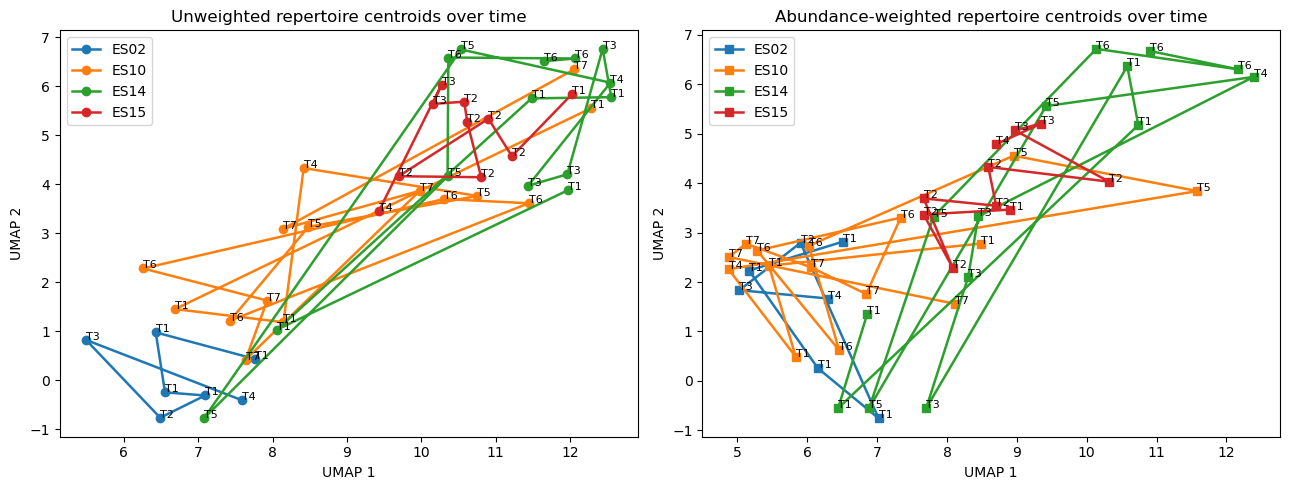

In [29]:
# ── Plot 4: Longitudinal repertoire trajectories ──

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# unweighted
for subj in SELECTED_SUBJECTS:
    sub = sample_summary[sample_summary["subject_id"] == subj].sort_values("tp_num")
    if len(sub) == 0:
        continue
    axes[0].plot(sub["umap1_unw"], sub["umap2_unw"], marker="o", lw=1.8, label=subj)
    for _, r in sub.iterrows():
        axes[0].text(r["umap1_unw"], r["umap2_unw"], str(r["timepoint"]), fontsize=8)

axes[0].set_title("Unweighted repertoire centroids over time")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[0].legend()

# weighted
for subj in SELECTED_SUBJECTS:
    sub = sample_summary[sample_summary["subject_id"] == subj].sort_values("tp_num")
    if len(sub) == 0:
        continue
    axes[1].plot(sub["umap1_w"], sub["umap2_w"], marker="s", lw=1.8, label=subj)
    for _, r in sub.iterrows():
        axes[1].text(r["umap1_w"], r["umap2_w"], str(r["timepoint"]), fontsize=8)

axes[1].set_title("Abundance-weighted repertoire centroids over time")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].legend()

plt.tight_layout()
plt.savefig(figure_dir / "longitudinal_repertoire_trajectories.png", dpi=200, bbox_inches="tight")
plt.show()

=== Null-test summary ===
          condition  n_samples  mean_within_sample_shift  median_within_sample_shift  mean_step_unweighted  mean_step_weighted  n_steps
    Real embeddings         46                  0.593286                    0.557454              0.545990            0.767910       42
Shuffled embeddings         46                  0.509490                    0.357175              0.600379            0.912992       42
    Shuffled counts         46                  0.449108                    0.309743              0.545990            0.998188       42
    Random Gaussian         46                  1.017248                    0.877385              1.146845            1.963409       42


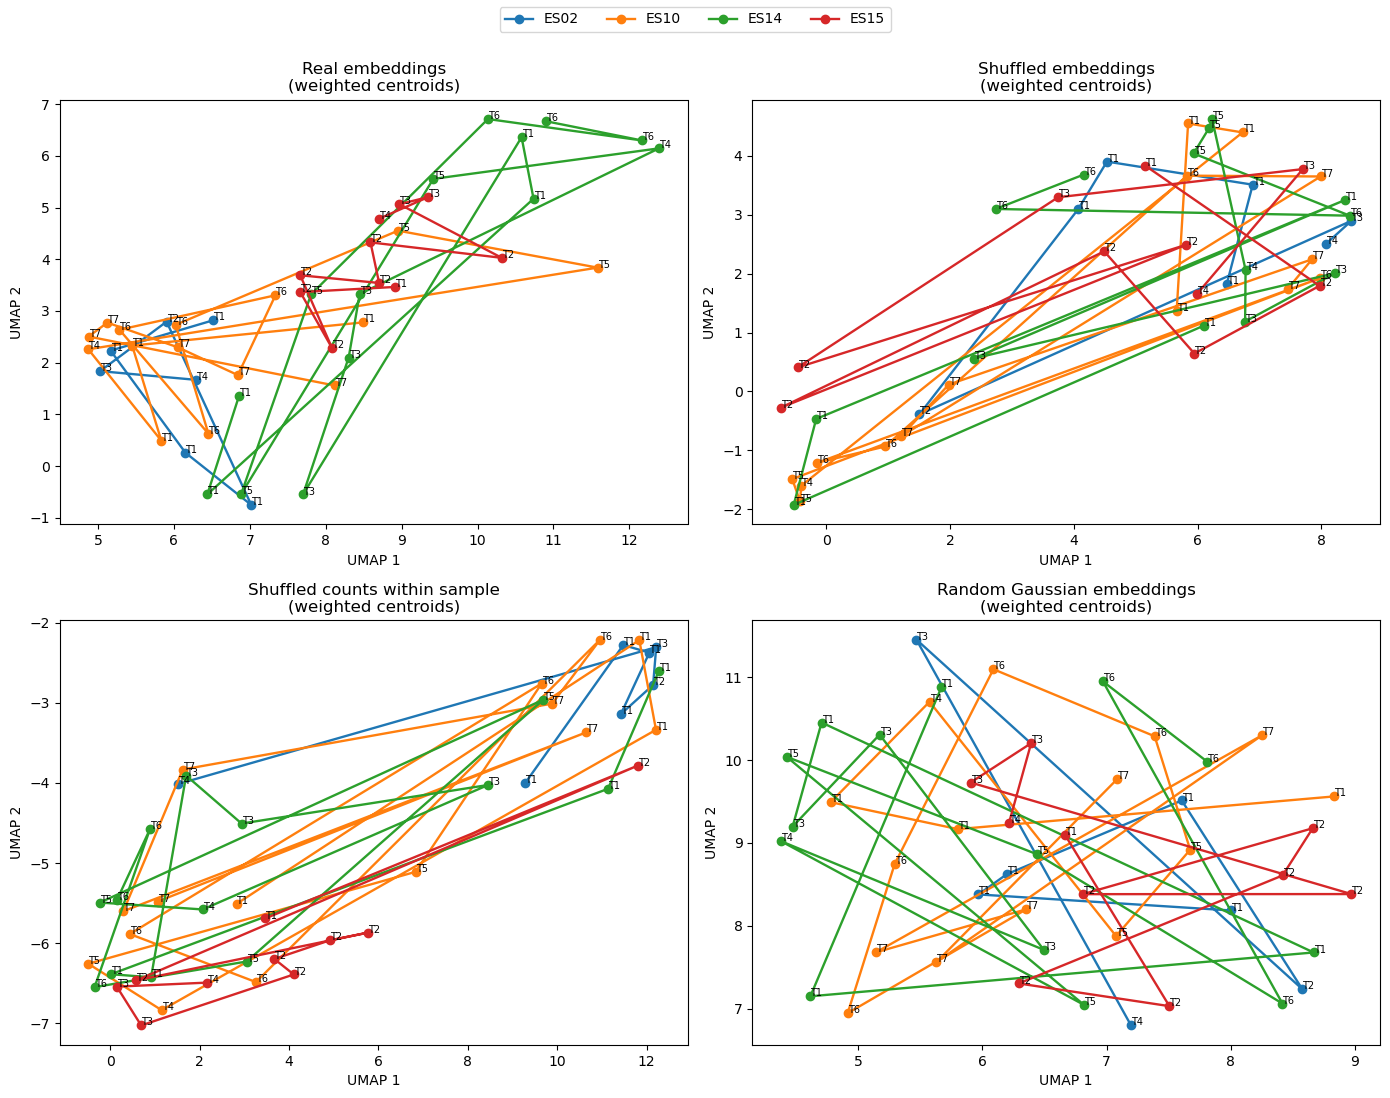

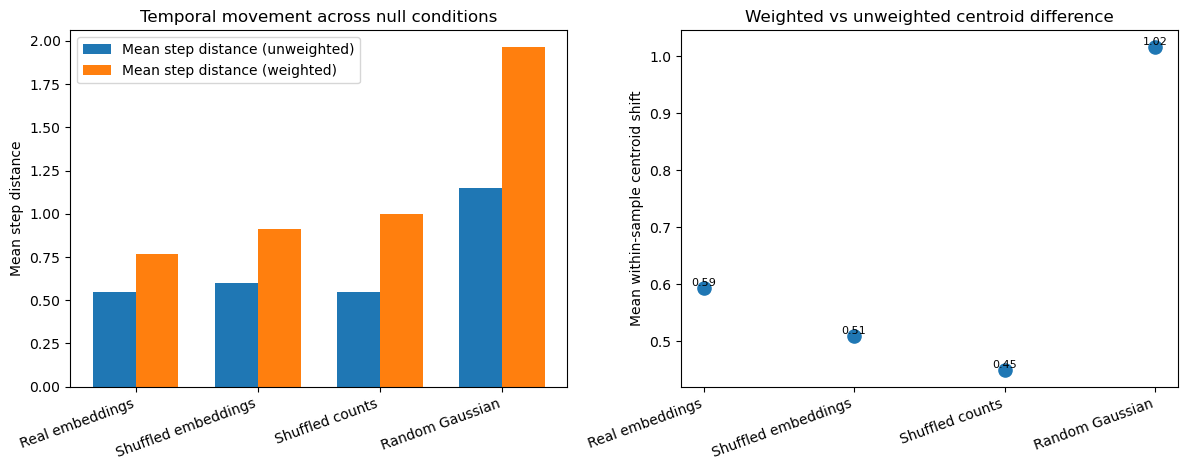

Saved: /home/natasha/multimodal_model/models/figures/icr_analysis/null_test_weighted_trajectories.png
Saved: /home/natasha/multimodal_model/models/figures/icr_analysis/null_test_summary_metrics.png


In [30]:
# test to make sure this result is meaningful

# ── Null tests for repertoire trajectory analysis ──
# This cell does NOT overwrite existing dataframes.
# It compares:
#   1) Real embeddings
#   2) Shuffled embeddings across clonotypes
#   3) Shuffled counts within each sample
#   4) Random Gaussian embeddings
#
# Required existing objects:
#   cs_embed            : sample-level dataframe with columns
#                         ["sample_id", "subject_id", "timepoint", "tissue", "total_count", "zT"]
#   SELECTED_SUBJECTS   : list of subjects to plot
#   figure_dir          : output directory
#
# Assumptions:
#   cs_embed["zT"] contains numpy arrays of identical dimension

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap

# -----------------------------
# 1. Defensive copy
# -----------------------------
cs_null = cs_embed.copy()

# Make sure zT exists and is usable
assert "zT" in cs_null.columns, "cs_embed must contain a 'zT' column"
assert "total_count" in cs_null.columns, "cs_embed must contain 'total_count'"
assert "sample_id" in cs_null.columns, "cs_embed must contain 'sample_id'"
assert "subject_id" in cs_null.columns, "cs_embed must contain 'subject_id'"
assert "timepoint" in cs_null.columns, "cs_embed must contain 'timepoint'"

# Convert list-like embeddings into a 2D matrix
Z_real = np.vstack(cs_null["zT"].values)
d_latent = Z_real.shape[1]

rng = np.random.default_rng(42)

# -----------------------------
# 2. Build null versions
# -----------------------------

# (A) Real embeddings
cs_null["z_real"] = list(Z_real)

# (B) Shuffled embeddings across all clonotype-sample rows
perm = rng.permutation(len(cs_null))
Z_shuf_embed = Z_real[perm]
cs_null["z_shuf_embed"] = list(Z_shuf_embed)

# (C) Random Gaussian embeddings with same dimensionality
Z_rand = rng.normal(size=Z_real.shape)
cs_null["z_rand"] = list(Z_rand)

# (D) Shuffled counts within each sample
# keep embeddings fixed, only permute counts within sample
def permute_within_group(x):
    arr = x.to_numpy().copy()
    rng.shuffle(arr)
    return pd.Series(arr, index=x.index)

cs_null["count_shuf_within_sample"] = (
    cs_null.groupby("sample_id", group_keys=False)["total_count"]
    .apply(permute_within_group)
)

# -----------------------------
# 3. Helper functions
# -----------------------------
def compute_centroid(arrs, weights=None):
    X = np.vstack(arrs)
    if weights is None:
        return X.mean(axis=0)
    w = np.asarray(weights, dtype=float)
    if w.sum() <= 0:
        return X.mean(axis=0)
    return np.average(X, axis=0, weights=w)

def build_sample_summary(df, z_col, weight_col="total_count"):
    rows = []
    for (sample_id, subject_id, timepoint, tissue), g in df.groupby(
        ["sample_id", "subject_id", "timepoint", "tissue"], dropna=False
    ):
        arrs = g[z_col].tolist()
        weights = g[weight_col].astype(float).to_numpy()

        c_unw = compute_centroid(arrs, weights=None)
        c_w   = compute_centroid(arrs, weights=weights)

        rows.append({
            "sample_id": sample_id,
            "subject_id": subject_id,
            "timepoint": timepoint,
            "tissue": tissue,
            "n_clonotypes": len(g),
            "total_reads_used": g[weight_col].sum(),
            "centroid_unweighted": c_unw,
            "centroid_weighted": c_w,
            "centroid_shift_within_sample": np.linalg.norm(c_w - c_unw),
        })

    out = pd.DataFrame(rows)
    out["tp_num"] = (
        out["timepoint"].astype(str).str.extract(r"(\d+)")[0].astype(float)
    )
    return out

def add_2d_projection(summary_df, random_state=42):
    # project both weighted and unweighted centroids together into one 2D space
    C_unw = np.vstack(summary_df["centroid_unweighted"].values)
    C_w   = np.vstack(summary_df["centroid_weighted"].values)
    C_all = np.vstack([C_unw, C_w])

    # PCA before UMAP for stability
    C_pca = PCA(n_components=min(10, C_all.shape[1]), random_state=random_state).fit_transform(C_all)
    reducer = umap.UMAP(
        n_neighbors=max(2, min(10, len(C_all) - 1)),
        min_dist=0.2,
        metric="euclidean",
        random_state=random_state,
    )
    Y = reducer.fit_transform(C_pca)

    out = summary_df.copy()
    n = len(out)
    out["umap1_unw"] = Y[:n, 0]
    out["umap2_unw"] = Y[:n, 1]
    out["umap1_w"]   = Y[n:, 0]
    out["umap2_w"]   = Y[n:, 1]
    return out

def build_temporal_steps(summary_df):
    rows = []
    for subj, sub in summary_df.groupby("subject_id"):
        sub = sub.sort_values("tp_num")
        if len(sub) < 2:
            continue
        for i in range(len(sub) - 1):
            a = sub.iloc[i]
            b = sub.iloc[i + 1]
            rows.append({
                "subject_id": subj,
                "from_tp": a["timepoint"],
                "to_tp": b["timepoint"],
                "delta_tp": b["tp_num"] - a["tp_num"],
                "step_dist_unweighted": np.linalg.norm(b["centroid_unweighted"] - a["centroid_unweighted"]),
                "step_dist_weighted": np.linalg.norm(b["centroid_weighted"] - a["centroid_weighted"]),
            })
    return pd.DataFrame(rows)

def summarise_condition(name, summary_df, steps_df):
    out = {
        "condition": name,
        "n_samples": len(summary_df),
        "mean_within_sample_shift": summary_df["centroid_shift_within_sample"].mean(),
        "median_within_sample_shift": summary_df["centroid_shift_within_sample"].median(),
        "mean_step_unweighted": steps_df["step_dist_unweighted"].mean() if len(steps_df) else np.nan,
        "mean_step_weighted": steps_df["step_dist_weighted"].mean() if len(steps_df) else np.nan,
        "n_steps": len(steps_df),
    }
    return out

# -----------------------------
# 4. Build summaries for each condition
# -----------------------------
summary_real = build_sample_summary(cs_null, z_col="z_real", weight_col="total_count")
summary_real = add_2d_projection(summary_real, random_state=42)
steps_real = build_temporal_steps(summary_real)

summary_shuf_embed = build_sample_summary(cs_null, z_col="z_shuf_embed", weight_col="total_count")
summary_shuf_embed = add_2d_projection(summary_shuf_embed, random_state=42)
steps_shuf_embed = build_temporal_steps(summary_shuf_embed)

summary_shuf_count = build_sample_summary(cs_null, z_col="z_real", weight_col="count_shuf_within_sample")
summary_shuf_count = add_2d_projection(summary_shuf_count, random_state=42)
steps_shuf_count = build_temporal_steps(summary_shuf_count)

summary_rand = build_sample_summary(cs_null, z_col="z_rand", weight_col="total_count")
summary_rand = add_2d_projection(summary_rand, random_state=42)
steps_rand = build_temporal_steps(summary_rand)

# -----------------------------
# 5. Numeric summary table
# -----------------------------
null_summary = pd.DataFrame([
    summarise_condition("Real embeddings", summary_real, steps_real),
    summarise_condition("Shuffled embeddings", summary_shuf_embed, steps_shuf_embed),
    summarise_condition("Shuffled counts", summary_shuf_count, steps_shuf_count),
    summarise_condition("Random Gaussian", summary_rand, steps_rand),
])

print("=== Null-test summary ===")
print(null_summary.to_string(index=False))

# -----------------------------
# 6. Plot weighted trajectories for each condition
# -----------------------------
def plot_weighted_trajectories(ax, summary_df, title):
    for subj in SELECTED_SUBJECTS:
        sub = summary_df[summary_df["subject_id"] == subj].sort_values("tp_num")
        if len(sub) == 0:
            continue
        ax.plot(sub["umap1_w"], sub["umap2_w"], marker="o", lw=1.7, label=subj)
        for _, r in sub.iterrows():
            ax.text(r["umap1_w"], r["umap2_w"], str(r["timepoint"]), fontsize=7)
    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

plot_weighted_trajectories(axes[0, 0], summary_real,       "Real embeddings\n(weighted centroids)")
plot_weighted_trajectories(axes[0, 1], summary_shuf_embed, "Shuffled embeddings\n(weighted centroids)")
plot_weighted_trajectories(axes[1, 0], summary_shuf_count, "Shuffled counts within sample\n(weighted centroids)")
plot_weighted_trajectories(axes[1, 1], summary_rand,       "Random Gaussian embeddings\n(weighted centroids)")

# single legend
handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=len(SELECTED_SUBJECTS), frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(figure_dir / "null_test_weighted_trajectories.png", dpi=220, bbox_inches="tight")
plt.show()

# -----------------------------
# 7. Plot compact quantitative comparison
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# mean step distance
x = np.arange(len(null_summary))
w = 0.35

axes[0].bar(
    x - w/2,
    null_summary["mean_step_unweighted"],
    width=w,
    label="Mean step distance (unweighted)"
)
axes[0].bar(
    x + w/2,
    null_summary["mean_step_weighted"],
    width=w,
    label="Mean step distance (weighted)"
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(null_summary["condition"], rotation=20, ha="right")
axes[0].set_ylabel("Mean step distance")
axes[0].set_title("Temporal movement across null conditions")
axes[0].legend()

# within-sample weighted-vs-unweighted shift
axes[1].scatter(
    x,
    null_summary["mean_within_sample_shift"],
    s=90
)
for i, row in null_summary.iterrows():
    axes[1].text(i, row["mean_within_sample_shift"], f"{row['mean_within_sample_shift']:.2f}",
                 fontsize=8, ha="center", va="bottom")
axes[1].set_xticks(x)
axes[1].set_xticklabels(null_summary["condition"], rotation=20, ha="right")
axes[1].set_ylabel("Mean within-sample centroid shift")
axes[1].set_title("Weighted vs unweighted centroid difference")

plt.tight_layout()
plt.savefig(figure_dir / "null_test_summary_metrics.png", dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_dir / 'null_test_weighted_trajectories.png'}")
print(f"Saved: {figure_dir / 'null_test_summary_metrics.png'}")


In [29]:
# ── Step 11: Quantify temporal movement between timepoints ──

temporal_steps = []

for subj, sub in sample_summary.groupby("subject_id"):
    sub = sub.sort_values("tp_num")
    if len(sub) < 2:
        continue

    for i in range(len(sub) - 1):
        a = sub.iloc[i]
        b = sub.iloc[i + 1]

        temporal_steps.append({
            "subject_id": subj,
            "from_tp": a["timepoint"],
            "to_tp": b["timepoint"],
            "delta_tp": b["tp_num"] - a["tp_num"],
            "step_dist_unweighted": np.linalg.norm(b["centroid_unweighted"] - a["centroid_unweighted"]),
            "step_dist_weighted": np.linalg.norm(b["centroid_weighted"] - a["centroid_weighted"]),
            "shift_a_within_sample": a["centroid_shift_within_sample"],
            "shift_b_within_sample": b["centroid_shift_within_sample"],
        })

temporal_steps = pd.DataFrame(temporal_steps)
print(temporal_steps)

   subject_id from_tp to_tp  delta_tp  step_dist_unweighted  \
0        ES02      T1    T1       0.0              0.406846   
1        ES02      T1    T1       0.0              0.281737   
2        ES02      T1    T1       0.0              0.137602   
3        ES02      T1    T2       1.0              0.114607   
4        ES02      T2    T3       1.0              2.034742   
5        ES02      T3    T4       1.0              2.316460   
6        ES10      T1    T1       0.0              0.884056   
7        ES10      T1    T1       0.0              0.328270   
8        ES10      T1    T4       3.0              0.622592   
9        ES10      T4    T5       1.0              0.493227   
10       ES10      T5    T5       0.0              0.333741   
11       ES10      T5    T6       1.0              0.428969   
12       ES10      T6    T6       0.0              0.396454   
13       ES10      T6    T6       0.0              0.232166   
14       ES10      T6    T6       0.0              0.71

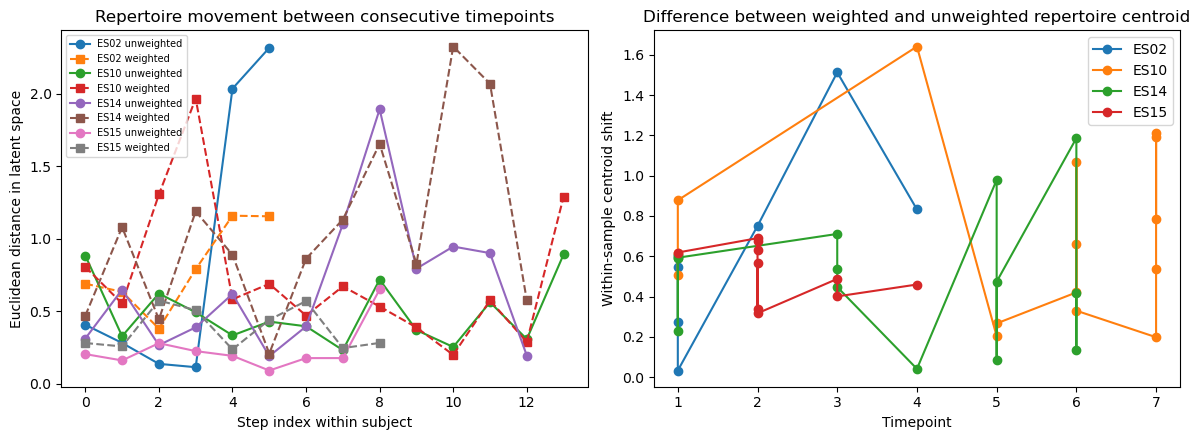

In [30]:
# ── Plot 5: Temporal shift magnitude ──

if len(temporal_steps) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # per-subject step distances
    for subj in SELECTED_SUBJECTS:
        sub = temporal_steps[temporal_steps["subject_id"] == subj].copy()
        if len(sub) == 0:
            continue
        x = np.arange(len(sub))
        axes[0].plot(x, sub["step_dist_unweighted"], marker="o", lw=1.5, label=f"{subj} unweighted")
        axes[0].plot(x, sub["step_dist_weighted"], marker="s", lw=1.5, linestyle="--", label=f"{subj} weighted")

    axes[0].set_title("Repertoire movement between consecutive timepoints")
    axes[0].set_xlabel("Step index within subject")
    axes[0].set_ylabel("Euclidean distance in latent space")
    axes[0].legend(fontsize=7)

    # within-sample divergence
    for subj in SELECTED_SUBJECTS:
        sub = sample_summary[sample_summary["subject_id"] == subj].sort_values("tp_num")
        if len(sub) == 0:
            continue
        axes[1].plot(sub["tp_num"], sub["centroid_shift_within_sample"], marker="o", lw=1.5, label=subj)

    axes[1].set_title("Difference between weighted and unweighted repertoire centroid")
    axes[1].set_xlabel("Timepoint")
    axes[1].set_ylabel("Within-sample centroid shift")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(figure_dir / "temporal_shift_magnitude.png", dpi=200, bbox_inches="tight")
    plt.show()

In [31]:
# ── Step 12: Summary tables ──

patient_summary = (
    sample_summary.groupby("subject_id", as_index=False)
    .agg(
        n_samples=("sample_id", "nunique"),
        n_timepoints=("tp_num", "nunique"),
        mean_reads=("total_reads", "mean"),
        mean_clonotypes=("n_clonotypes", "mean"),
        mean_within_sample_shift=("centroid_shift_within_sample", "mean"),
    )
)

print("Patient-level summary")
print(patient_summary.to_string(index=False))

if len(temporal_steps) > 0:
    movement_summary = (
        temporal_steps.groupby("subject_id", as_index=False)
        .agg(
            mean_step_unweighted=("step_dist_unweighted", "mean"),
            mean_step_weighted=("step_dist_weighted", "mean"),
            n_steps=("subject_id", "size"),
        )
    )
    print("\nTemporal movement summary")
    print(movement_summary.to_string(index=False))

Patient-level summary
subject_id  n_samples  n_timepoints  mean_reads  mean_clonotypes  mean_within_sample_shift
      ES02          7             4 3789.571429      1779.571429                  0.650041
      ES10         15             5  818.733333       201.333333                  0.701552
      ES14         14             5 1239.428571       325.714286                  0.502122
      ES15         10             4 3220.800000       874.200000                  0.518789

Temporal movement summary
subject_id  mean_step_unweighted  mean_step_weighted  n_steps
      ES02              0.881999            0.801450        6
      ES10              0.487525            0.737180       14
      ES14              0.665610            1.055752       13
      ES15              0.240145            0.377579        9


Old Analysis (Too Complex)

## Section 4: Compute Pseudo-Binding Scores

For each ICR clonotype, query the kNN index over the reference set.
The **pseudo-binding score** = proportion of k nearest neighbours that are labelled binders.
We also compute a distance-weighted variant.

In [41]:
# ── Compute pseudo-binding scores for the embedded subset ──

icr_zT_norm = icr_zT / (np.linalg.norm(icr_zT, axis=1, keepdims=True) + 1e-12)

distances, indices = knn.kneighbors(icr_zT_norm)

# Unweighted: proportion of binder neighbours
neighbour_labels = ref_labels[indices]  # (N_subset, K)
pseudo_binding_score = neighbour_labels.mean(axis=1)

# Distance-weighted: closer neighbours count more
weights = 1.0 / (distances + 1e-8)
weights = weights / weights.sum(axis=1, keepdims=True)
pseudo_binding_score_weighted = (neighbour_labels * weights).sum(axis=1)

# Attach to clono_embed
clono_embed["pseudo_binding"] = pseudo_binding_score
clono_embed["pseudo_binding_weighted"] = pseudo_binding_score_weighted
clono_embed["mean_knn_distance"] = distances.mean(axis=1)

# Map back to clono_global (NaN for un-embedded clonotypes)
pbs_map_embed = clono_embed.set_index("sequence_aa")["pseudo_binding"].to_dict()
pbs_w_map_embed = clono_embed.set_index("sequence_aa")["pseudo_binding_weighted"].to_dict()

clono_global["pseudo_binding"] = clono_global["sequence_aa"].map(pbs_map_embed)
clono_global["pseudo_binding_weighted"] = clono_global["sequence_aa"].map(pbs_w_map_embed)

n_scored = clono_global["pseudo_binding"].notna().sum()
print(f"Pseudo-binding scores computed for {n_scored} / {len(clono_global)} clonotypes")
print(f"  ({len(clono_global) - n_scored} un-embedded singletons left as NaN)")
print(f"  Mean score (subset): {pseudo_binding_score.mean():.4f}")
print(f"  Range: [{pseudo_binding_score.min():.3f}, {pseudo_binding_score.max():.3f}]")

Pseudo-binding scores computed for 14538 / 133936 clonotypes
  (119398 un-embedded singletons left as NaN)
  Mean score (subset): 0.9704
  Range: [0.333, 1.000]


---
## Analysis 1: Association Between Embedding-Derived Binding Score and Clonal Expansion

**Hypothesis**: If the embedding space captures biologically meaningful binding signal, clonotypes with higher pseudo-binding scores should tend to be more clonally expanded (higher abundance), reflecting antigen-driven proliferation.

In [42]:
# ── 1a: Correlation analysis ──
# Use only clonotypes that were embedded (have a pseudo-binding score)

scored = clono_global.dropna(subset=["pseudo_binding"]).copy()
print(f"Using {len(scored)} scored clonotypes for Analysis 1")
print(f"  of which {(scored['total_count_all'] >= MIN_COUNT).sum()} are expanded")

expansion = scored["log_total_count_all"].values
pbs = scored["pseudo_binding"].values
pbs_w = scored["pseudo_binding_weighted"].values

rho_spearman, p_spearman = spearmanr(pbs, expansion)
r_pearson, p_pearson     = pearsonr(pbs, expansion)
rho_w, p_w               = spearmanr(pbs_w, expansion)

print(f"\n=== Correlation: Pseudo-Binding Score vs Clonal Expansion ===")
print(f"Unweighted:")
print(f"  Spearman ρ = {rho_spearman:.4f}  (p = {p_spearman:.2e})")
print(f"  Pearson  r = {r_pearson:.4f}  (p = {p_pearson:.2e})")
print(f"Distance-weighted:")
print(f"  Spearman ρ = {rho_w:.4f}  (p = {p_w:.2e})")

Using 14538 scored clonotypes for Analysis 1
  of which 4079 are expanded

=== Correlation: Pseudo-Binding Score vs Clonal Expansion ===
Unweighted:
  Spearman ρ = 0.0325  (p = 8.97e-05)
  Pearson  r = 0.0401  (p = 1.28e-06)
Distance-weighted:
  Spearman ρ = 0.0180  (p = 2.98e-02)


In [43]:
# ── 1b: Quantile stratification ──

n_bins = 10
scored["pbs_quantile"] = pd.qcut(scored["pseudo_binding"],
                                  q=n_bins, labels=False, duplicates="drop")

quantile_stats = (
    scored.groupby("pbs_quantile")
    .agg(
        mean_expansion=("log_total_count_all", "mean"),
        median_expansion=("log_total_count_all", "median"),
        mean_pbs=("pseudo_binding", "mean"),
        count=("sequence_aa", "size"),
    )
    .reset_index()
)

print("=== Quantile Stratification ===")
print(quantile_stats.to_string(index=False))

=== Quantile Stratification ===
 pbs_quantile  mean_expansion  median_expansion  mean_pbs  count
            0        1.048940          0.693147  0.753103   1531
            1        1.140759          0.693147  0.995969  13007


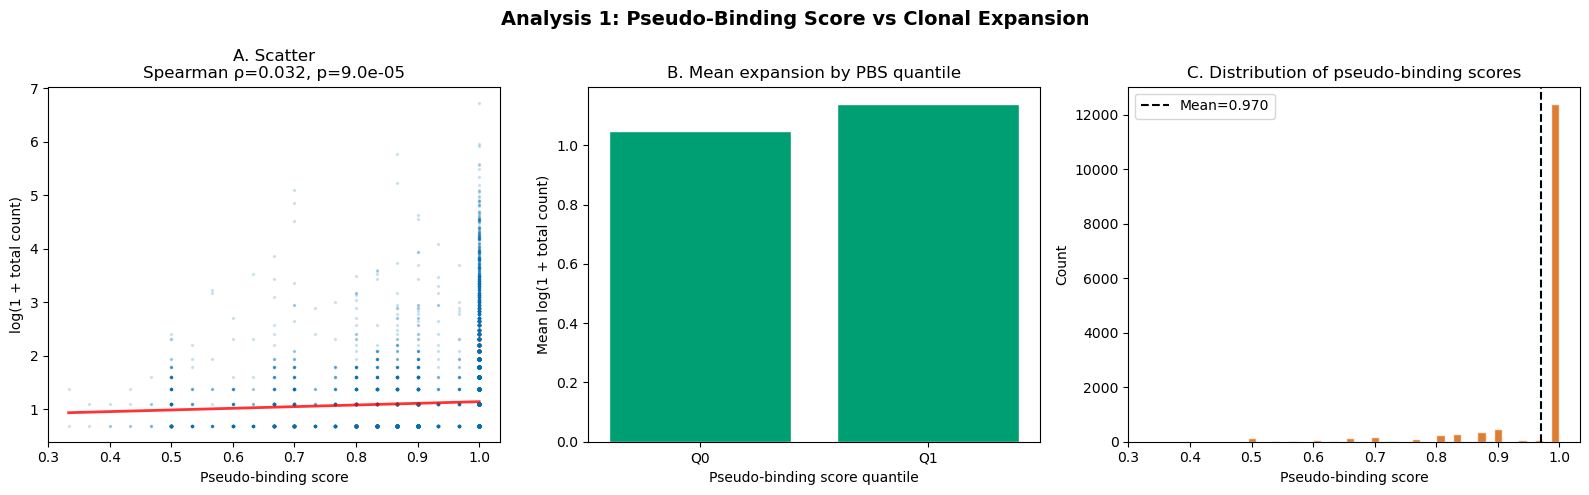

Saved: /home/natasha/multimodal_model/models/figures/icr_analysis/analysis1_binding_vs_expansion.png


In [44]:
# ── 1c: Figure — Analysis 1 multi-panel ──

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Analysis 1: Pseudo-Binding Score vs Clonal Expansion",
             fontsize=14, fontweight="bold")

# Panel A: Scatter
ax = axes[0]
ax.scatter(pbs, expansion, s=2, alpha=0.15, color="#0072B2", rasterized=True)
# Trend line
z = np.polyfit(pbs, expansion, 1)
x_line = np.linspace(pbs.min(), pbs.max(), 100)
ax.plot(x_line, np.polyval(z, x_line), "r-", lw=2, alpha=0.8)
ax.set_xlabel("Pseudo-binding score")
ax.set_ylabel("log(1 + total count)")
ax.set_title(f"A. Scatter\nSpearman ρ={rho_spearman:.3f}, p={p_spearman:.1e}")

# Panel B: Quantile bar chart
ax = axes[1]
ax.bar(quantile_stats["pbs_quantile"], quantile_stats["mean_expansion"],
       color="#009E73", edgecolor="white", width=0.8)
ax.set_xlabel("Pseudo-binding score quantile")
ax.set_ylabel("Mean log(1 + total count)")
ax.set_title("B. Mean expansion by PBS quantile")
ax.set_xticks(quantile_stats["pbs_quantile"])
ax.set_xticklabels([f"Q{int(q)}" for q in quantile_stats["pbs_quantile"]])

# Panel C: Distribution of PBS
ax = axes[2]
ax.hist(pbs, bins=50, color="#D55E00", edgecolor="white", alpha=0.8)
ax.axvline(pbs.mean(), color="black", ls="--", lw=1.5, label=f"Mean={pbs.mean():.3f}")
ax.set_xlabel("Pseudo-binding score")
ax.set_ylabel("Count")
ax.set_title("C. Distribution of pseudo-binding scores")
ax.legend()

plt.tight_layout()
plt.savefig(figure_dir / "analysis1_binding_vs_expansion.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_dir / 'analysis1_binding_vs_expansion.png'}")

In [19]:
# ── 1d: Top-scorer characterisation ──

top_pct = 0.05  # top 5% by pseudo-binding score
threshold = scored["pseudo_binding"].quantile(1 - top_pct)

top_binders = scored[scored["pseudo_binding"] >= threshold].copy()
rest = scored[scored["pseudo_binding"] < threshold]

print(f"=== Top {top_pct*100:.0f}% Pseudo-Binders (PBS ≥ {threshold:.3f}) ===")
print(f"  N clonotypes:     {len(top_binders)} / {len(scored)}")
print(f"  Mean expansion:   {top_binders['log_total_count_all'].mean():.3f} ")
print(f"    vs {rest['log_total_count_all'].mean():.3f} (rest)")
print(f"  Median expansion: {top_binders['log_total_count_all'].median():.3f} ")
print(f"    vs {rest['log_total_count_all'].median():.3f} (rest)")
print(f"  Mean n_samples:   {top_binders['n_samples'].mean():.2f} ")
print(f"    vs {rest['n_samples'].mean():.2f} (rest)")

=== Top 5% Pseudo-Binders (PBS ≥ 1.000) ===
  N clonotypes:     34999 / 39703
  Mean expansion:   1.885 
    vs 1.859 (rest)
  Median expansion: 1.609 
    vs 1.609 (rest)
  Mean n_samples:   1.44 
    vs 1.51 (rest)


---
## Analysis 2: Longitudinal Dynamics of Embedding-Derived Binding Signal

**Hypothesis**: If antigen-driven selection is ongoing, samples from later timepoints (or samples with higher clonal expansion) should show elevated pseudo-binding scores, reflecting enrichment of TCRs in the binder-associated region of embedding space.

In [45]:
# ── 2a: Propagate pseudo-binding scores to sample level ──

# Map clonotype → pseudo-binding score (only scored clonotypes have values)
pbs_map = clono_global.set_index("sequence_aa")["pseudo_binding"].to_dict()
pbs_w_map = clono_global.set_index("sequence_aa")["pseudo_binding_weighted"].to_dict()

clono_sample["pseudo_binding"] = clono_sample["sequence_aa"].map(pbs_map)
clono_sample["pseudo_binding_weighted"] = clono_sample["sequence_aa"].map(pbs_w_map)

# Diagnostic: how much coverage do we get per sample?
coverage = clono_sample.groupby("sample_id")["pseudo_binding"].apply(
    lambda x: x.notna().mean()
).rename("pbs_coverage")
print(f"PBS coverage per sample: mean={coverage.mean():.2%}, min={coverage.min():.2%}, max={coverage.max():.2%}")

# Filter to clonotypes with scores for aggregation
cs_scored = clono_sample.dropna(subset=["pseudo_binding"]).copy()
print(f"Clonotype-sample rows with PBS: {len(cs_scored)} / {len(clono_sample)}")

# Sample-level summaries (computed only from scored clonotypes)
sample_summary = (
    cs_scored.groupby(["sample_id", "subject_id", "timepoint", "tissue"])
    .agg(
        mean_pbs=("pseudo_binding", "mean"),
        median_pbs=("pseudo_binding", "median"),
        mean_pbs_weighted=("pseudo_binding_weighted", "mean"),
        mean_expansion=("log_total_count", "mean"),
        median_expansion=("log_total_count", "median"),
        richness=("sequence_aa", "nunique"),
        total_reads=("total_count", "sum"),
    )
    .reset_index()
)

# Abundance-weighted mean PBS (only over scored clonotypes)
def abundance_weighted_pbs(group):
    valid = group.dropna(subset=["pseudo_binding"])
    if len(valid) == 0:
        return np.nan
    weights = valid["total_count"].values.astype(float)
    scores = valid["pseudo_binding"].values
    if weights.sum() == 0:
        return np.nan
    return np.average(scores, weights=weights)

aw_pbs = (
    cs_scored.groupby("sample_id")
    .apply(abundance_weighted_pbs)
    .rename("abundance_weighted_pbs")
)
sample_summary = sample_summary.merge(aw_pbs, on="sample_id", how="left")

# Numeric timepoint
sample_summary["tp_num"] = (
    sample_summary["timepoint"].str.extract(r"(\d+)").astype(float)
)

n_with_pbs = sample_summary["abundance_weighted_pbs"].notna().sum()
print(f"\nSample-level summary: {len(sample_summary)} samples, {n_with_pbs} with PBS values")
sample_summary.head(10)

PBS coverage per sample: mean=17.49%, min=0.00%, max=100.00%
Clonotype-sample rows with PBS: 17872 / 153254

Sample-level summary: 98 samples, 98 with PBS values


,sample_id,subject_id,timepoint,tissue,mean_pbs,median_pbs,mean_pbs_weighted,mean_expansion,median_expansion,richness,total_reads,abundance_weighted_pbs,tp_num
0,ES01_T1_Bo_C3,ES01,T1,Bo,0.966667,1.0,0.969020,0.693147,0.693147,3,3,0.966667,1.0
1,ES01_T2_Lu_C1,ES01,T2,Lu,1.000000,1.0,1.000000,1.386294,1.386294,1,3,1.000000,2.0
2,ES02_T1_Bo_C3,ES02,T1,Bo,0.970081,1.0,0.970416,1.329243,1.098612,1230,4728,0.978102,1.0
3,ES02_T1_Bo_C4,ES02,T1,Bo,0.971354,1.0,0.971828,0.978218,0.693147,576,1227,0.980902,1.0
4,ES02_T1_Bo_C5,ES02,T1,Bo,0.966440,1.0,0.966921,1.104767,1.098612,1908,5081,0.965584,1.0
5,ES02_T1_Bo_C6,ES02,T1,Bo,0.969266,1.0,0.969798,0.905522,0.693147,8464,13926,0.970087,1.0
6,ES02_T2_Lu_C1,ES02,T2,Lu,0.965931,1.0,0.966770,1.755752,1.386294,136,1164,0.972566,2.0
7,ES02_T3_Lu_C8,ES02,T3,Lu,0.919231,1.0,0.919227,1.288437,1.098612,26,113,0.954572,3.0
8,ES02_T4_Li_C5,ES02,T4,Li,0.977208,1.0,0.977398,1.082989,0.693147,117,288,0.986921,4.0
9,ES03_T3_Li_C5,ES03,T3,Li,1.000000,1.0,1.000000,0.895880,0.895880,2,3,1.000000,3.0


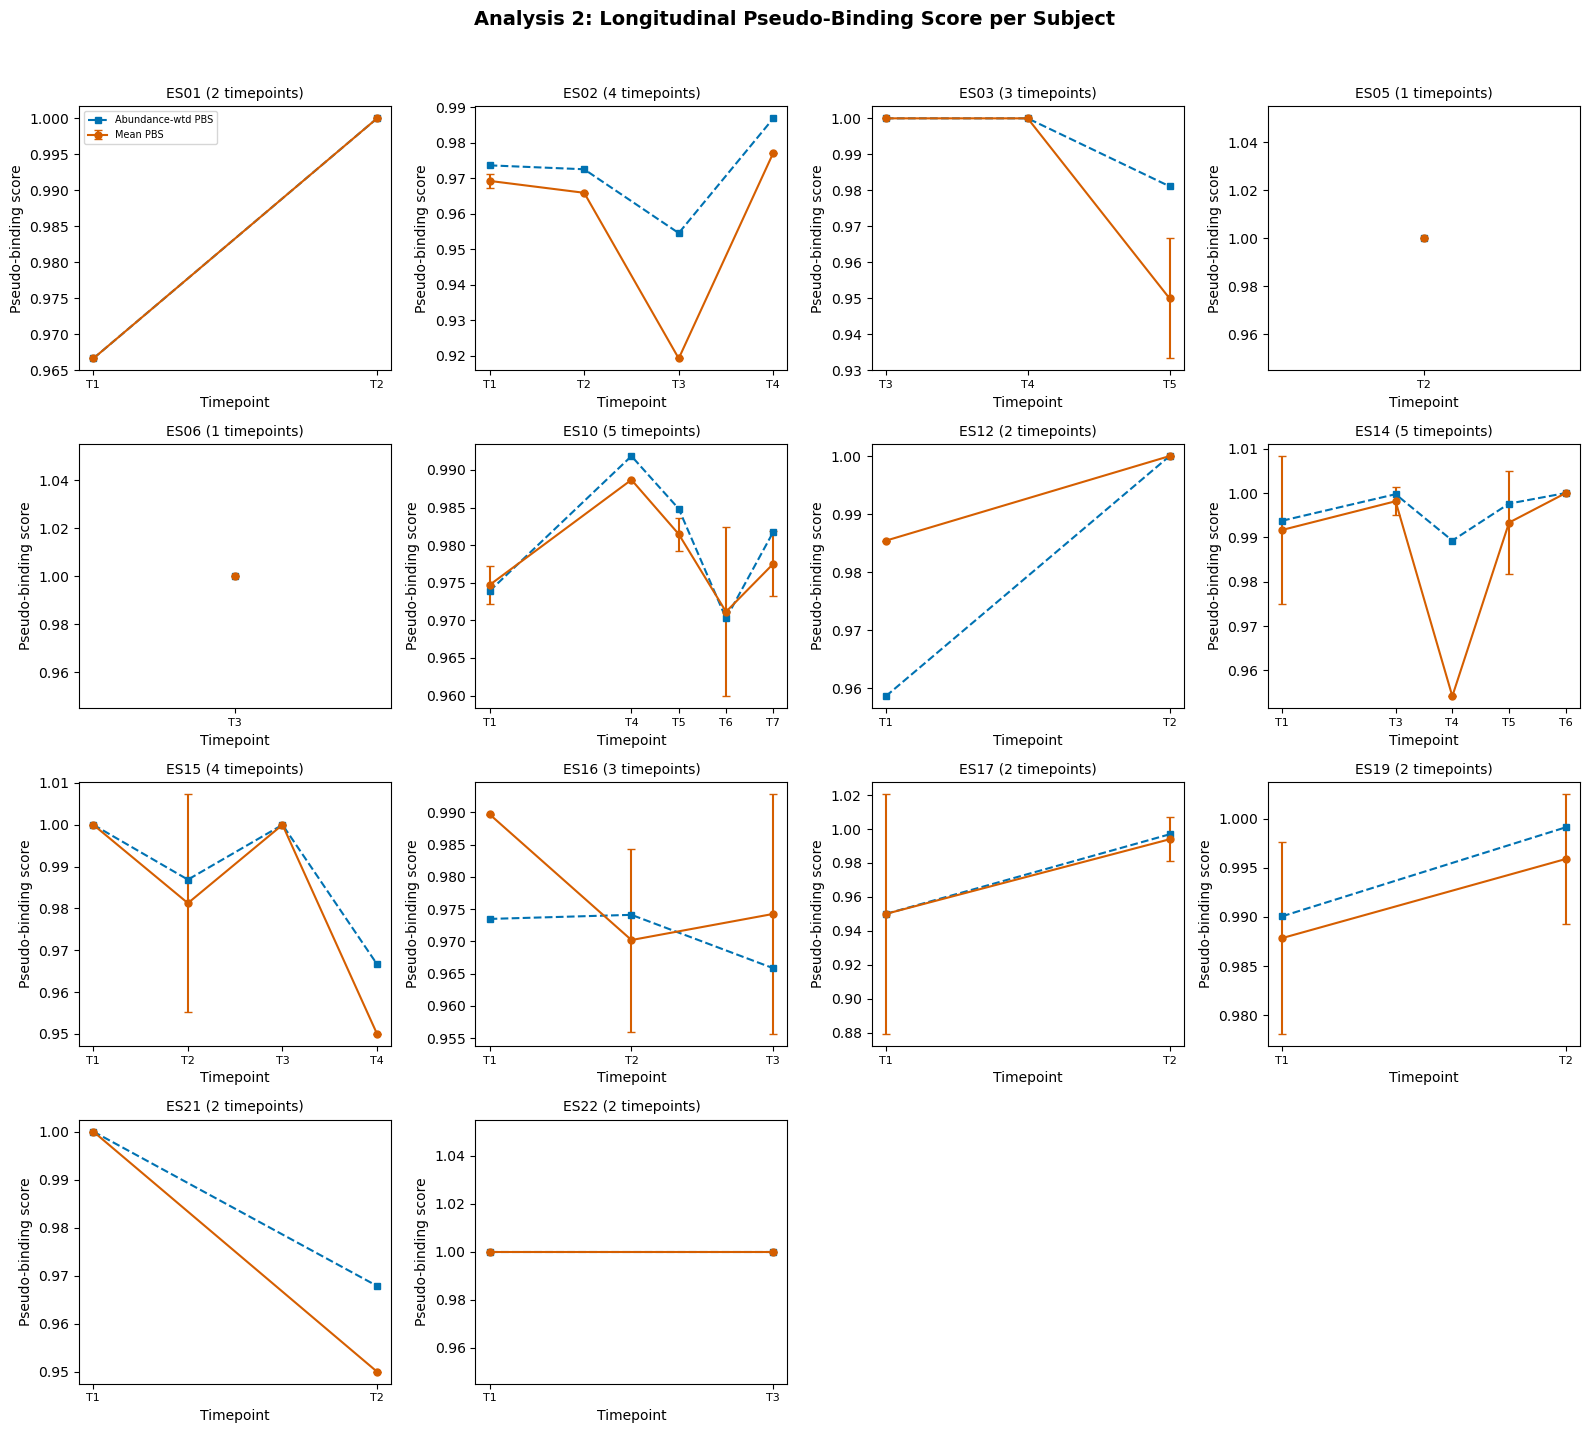

Saved: /home/natasha/multimodal_model/models/figures/icr_analysis/analysis2_longitudinal_pbs_per_subject.png


In [46]:
# ── 2b: Per-subject temporal trajectories ──

subjects = sorted(sample_summary["subject_id"].dropna().unique())
n_subjects = len(subjects)

ncols = 4
nrows = int(np.ceil(n_subjects / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows), squeeze=False)
fig.suptitle("Analysis 2: Longitudinal Pseudo-Binding Score per Subject",
             fontsize=14, fontweight="bold", y=1.02)

for idx, subj in enumerate(subjects):
    ax = axes[idx // ncols, idx % ncols]
    sub = sample_summary[sample_summary["subject_id"] == subj].sort_values("tp_num")
    
    if len(sub) < 2:
        ax.set_title(f"{subj} (1 timepoint)", fontsize=10)
        ax.set_visible(True)
        continue
    
    # Average across tissues per timepoint
    tp_avg = sub.groupby("tp_num").agg(
        mean_pbs=("mean_pbs", "mean"),
        std_pbs=("mean_pbs", "std"),
        mean_aw_pbs=("abundance_weighted_pbs", "mean"),
        mean_expansion=("mean_expansion", "mean"),
    ).reset_index()
    tp_avg["std_pbs"] = tp_avg["std_pbs"].fillna(0)
    
    # Plot PBS trajectory
    ax.errorbar(tp_avg["tp_num"], tp_avg["mean_pbs"],
                yerr=tp_avg["std_pbs"],
                color="#D55E00", marker="o", lw=1.5, markersize=5,
                capsize=3, label="Mean PBS")
    ax.plot(tp_avg["tp_num"], tp_avg["mean_aw_pbs"],
            "s--", color="#0072B2", lw=1.5, markersize=5,
            label="Abundance-wtd PBS")
    
    ax.set_xlabel("Timepoint")
    ax.set_ylabel("Pseudo-binding score")
    n_tp = sub["timepoint"].nunique()
    ax.set_title(f"{subj} ({n_tp} timepoints)", fontsize=10)
    ax.set_xticks(tp_avg["tp_num"])
    ax.set_xticklabels([f"T{int(t)}" for t in tp_avg["tp_num"]], fontsize=8)
    if idx == 0:
        ax.legend(fontsize=7)

# Hide unused axes
for idx in range(n_subjects, nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

plt.tight_layout()
plt.savefig(figure_dir / "analysis2_longitudinal_pbs_per_subject.png",
            dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_dir / 'analysis2_longitudinal_pbs_per_subject.png'}")

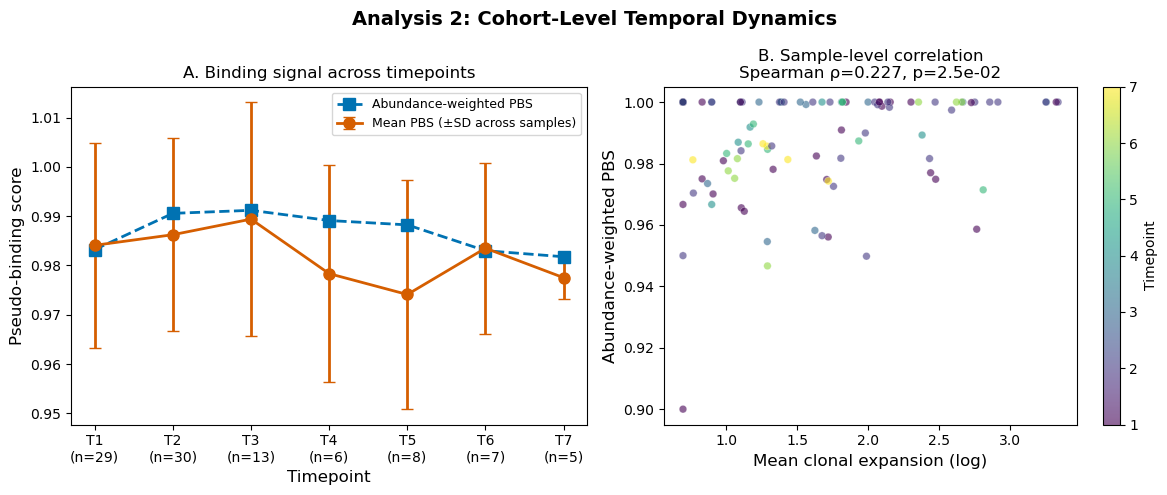

Saved: /home/natasha/multimodal_model/models/figures/icr_analysis/analysis2_cohort_temporal.png


In [47]:
# ── 2c: Cohort-level temporal trend ──

# Aggregate across all subjects per timepoint number
cohort_temporal = (
    sample_summary.dropna(subset=["tp_num"])
    .groupby("tp_num")
    .agg(
        mean_pbs=("mean_pbs", "mean"),
        std_pbs=("mean_pbs", "std"),
        mean_aw_pbs=("abundance_weighted_pbs", "mean"),
        mean_expansion=("mean_expansion", "mean"),
        n_samples=("sample_id", "size"),
    )
    .reset_index()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Analysis 2: Cohort-Level Temporal Dynamics",
             fontsize=14, fontweight="bold")

# Left: PBS over time
ax1.errorbar(cohort_temporal["tp_num"], cohort_temporal["mean_pbs"],
             yerr=cohort_temporal["std_pbs"],
             color="#D55E00", marker="o", lw=2, markersize=8, capsize=4,
             label="Mean PBS (±SD across samples)")
ax1.plot(cohort_temporal["tp_num"], cohort_temporal["mean_aw_pbs"],
         "s--", color="#0072B2", lw=2, markersize=8,
         label="Abundance-weighted PBS")
ax1.set_xlabel("Timepoint", fontsize=12)
ax1.set_ylabel("Pseudo-binding score", fontsize=12)
ax1.set_title("A. Binding signal across timepoints")
ax1.set_xticks(cohort_temporal["tp_num"])
ax1.set_xticklabels([f"T{int(t)}\n(n={int(n)})" for t, n
                      in zip(cohort_temporal["tp_num"], cohort_temporal["n_samples"])])
ax1.legend(fontsize=9)

# Right: PBS vs expansion scatter (sample-level)
ax2.scatter(sample_summary["mean_expansion"],
            sample_summary["abundance_weighted_pbs"],
            s=30, alpha=0.6, c=sample_summary["tp_num"],
            cmap="viridis", edgecolors="white", lw=0.3)
_corr_df = sample_summary[["mean_expansion", "abundance_weighted_pbs"]].dropna()
if len(_corr_df) >= 3:
    rho_s, p_s = spearmanr(_corr_df["mean_expansion"], _corr_df["abundance_weighted_pbs"])
else:
    rho_s, p_s = float("nan"), float("nan")
    print(f"WARNING: only {len(_corr_df)} samples with both expansion and PBS — cannot compute correlation.")
ax2.set_xlabel("Mean clonal expansion (log)", fontsize=12)
ax2.set_ylabel("Abundance-weighted PBS", fontsize=12)
ax2.set_title(f"B. Sample-level correlation\nSpearman ρ={rho_s:.3f}, p={p_s:.1e}")
cb = plt.colorbar(ax2.collections[0], ax=ax2, label="Timepoint")

plt.tight_layout()
plt.savefig(figure_dir / "analysis2_cohort_temporal.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_dir / 'analysis2_cohort_temporal.png'}")

In [48]:
# ── 2d: Clonotype-level longitudinal tracking ──
# For clonotypes observed at multiple timepoints within a subject,
# check whether high-PBS clonotypes are preferentially expanded over time.

# Only use clonotypes that have pseudo-binding scores
cs_scored = clono_sample.dropna(subset=["pseudo_binding", "timepoint", "subject_id"]).copy()
cs_scored["tp_num"] = cs_scored["timepoint"].str.extract(r"(\d+)").astype(int)

# Get first and last observation per (subject, clonotype)
cs_sorted = cs_scored.sort_values(["subject_id", "sequence_aa", "tp_num"])

first_obs = cs_sorted.groupby(["subject_id", "sequence_aa"]).first().reset_index()
last_obs = cs_sorted.groupby(["subject_id", "sequence_aa"]).last().reset_index()

# Keep only clonotypes seen at ≥2 distinct timepoints
n_tp = cs_scored.groupby(["subject_id", "sequence_aa"])["tp_num"].nunique().reset_index()
n_tp.columns = ["subject_id", "sequence_aa", "n_timepoints"]
multi_tp = n_tp[n_tp["n_timepoints"] >= 2][["subject_id", "sequence_aa"]]

first_obs = first_obs.merge(multi_tp, on=["subject_id", "sequence_aa"])
last_obs = last_obs.merge(multi_tp, on=["subject_id", "sequence_aa"])

# Compute log2 fold-change (vectorised)
clono_longitudinal = first_obs[["subject_id", "sequence_aa", "pseudo_binding"]].copy()
clono_longitudinal["count_first"] = first_obs["total_count"].values
clono_longitudinal["count_last"] = last_obs["total_count"].values
clono_longitudinal["tp_first"] = first_obs["tp_num"].values
clono_longitudinal["tp_last"] = last_obs["tp_num"].values
clono_longitudinal["log2_fc"] = np.log2(
    (clono_longitudinal["count_last"] + 1) /
    (clono_longitudinal["count_first"] + 1)
)

print(f"Clonotypes observed at ≥2 timepoints (with PBS): {len(clono_longitudinal)}")
print(f"Unique subjects: {clono_longitudinal['subject_id'].nunique()}")
print(f"Median fold-change: {clono_longitudinal['log2_fc'].median():.3f}")

Clonotypes observed at ≥2 timepoints (with PBS): 303
Unique subjects: 9
Median fold-change: 0.000


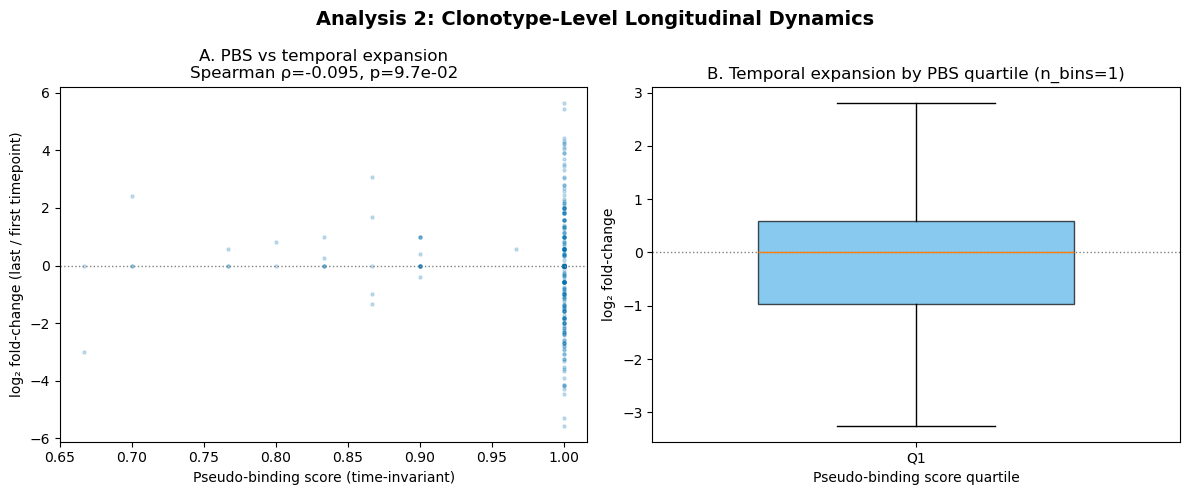

Saved: /home/natasha/multimodal_model/models/figures/icr_analysis/analysis2_clonotype_longitudinal.png


In [49]:
# ── 2e: Figure — PBS vs temporal fold-change ──

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Analysis 2: Clonotype-Level Longitudinal Dynamics",
             fontsize=14, fontweight="bold")

# Left: scatter of PBS vs fold-change
ax1.scatter(clono_longitudinal["pseudo_binding"],
            clono_longitudinal["log2_fc"],
            s=5, alpha=0.2, color="#0072B2", rasterized=True)
ax1.axhline(0, color="grey", ls=":", lw=1)
rho_fc, p_fc = spearmanr(
    clono_longitudinal["pseudo_binding"],
    clono_longitudinal["log2_fc"]
)
ax1.set_xlabel("Pseudo-binding score (time-invariant)")
ax1.set_ylabel("log₂ fold-change (last / first timepoint)")
ax1.set_title(f"A. PBS vs temporal expansion\nSpearman ρ={rho_fc:.3f}, p={p_fc:.1e}")

# Right: stratify by PBS quartile and show fold-change distribution
# Use labels=False first to handle duplicate bin edges, then map to names
clono_longitudinal["pbs_bin"] = pd.qcut(
    clono_longitudinal["pseudo_binding"], q=4,
    labels=False, duplicates="drop"
)
n_bins_actual = clono_longitudinal["pbs_bin"].nunique()
bin_names = {b: f"Q{b+1}" for b in range(n_bins_actual)}
if n_bins_actual >= 2:
    bin_names[min(bin_names)] = f"Q1 (low)"
    bin_names[max(bin_names)] = f"Q{n_bins_actual} (high)"
clono_longitudinal["pbs_quartile"] = clono_longitudinal["pbs_bin"].map(bin_names)

quartile_order = [bin_names[b] for b in sorted(bin_names)]
quartile_data = []
quartile_labels = []
for name in quartile_order:
    grp = clono_longitudinal[clono_longitudinal["pbs_quartile"] == name]["log2_fc"]
    if len(grp) > 0:
        quartile_data.append(grp.values)
        quartile_labels.append(name)

colors = ["#56B4E9", "#009E73", "#E69F00", "#D55E00"][:len(quartile_data)]
bp = ax2.boxplot(quartile_data, labels=quartile_labels, patch_artist=True,
                 showfliers=False, widths=0.6)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.axhline(0, color="grey", ls=":", lw=1)
ax2.set_xlabel("Pseudo-binding score quartile")
ax2.set_ylabel("log₂ fold-change")
ax2.set_title(f"B. Temporal expansion by PBS quartile (n_bins={n_bins_actual})")

plt.tight_layout()
plt.savefig(figure_dir / "analysis2_clonotype_longitudinal.png",
            dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_dir / 'analysis2_clonotype_longitudinal.png'}")

## Summary Statistics

In [50]:
# ── Print summary for methods section ──

print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"""\nModel: best_baseline_projection_model.pt
  Config: rL={cfg['rL']}, rD={cfg['rD']}, d={cfg['d']}, R_PH={cfg.get('R_PH', 0.7)}
  Best val AUROC: {checkpoint['best_val_metrics']['auroc']:.4f}
  Best val F1:    {checkpoint['best_val_metrics']['f1']:.4f}
  Best epoch:     {checkpoint['best_epoch']}
  Loss type:      {cfg.get('loss_type', 'unknown')}

Reference set: {ref_zT.shape[0]} TCR embeddings
  Binders: {ref_labels.sum()} ({ref_labels.mean()*100:.1f}%)
  kNN k={K_NEIGHBOURS}, metric=cosine

ICR dataset:
  Total rows:         {len(df)}
  Unique clonotypes:  {len(clono_global)}
  Embedded subset:    {len(clono_embed)} (expanded ≥{MIN_COUNT} reads + {N_BACKGROUND} background)
  Samples:            {df['sample_id'].nunique()}
  Subjects:           {sample_summary['subject_id'].nunique()}

Analysis 1 (binding vs expansion):
  Scored clonotypes: {len(scored)}
  Spearman ρ = {rho_spearman:.4f} (p = {p_spearman:.2e})
  Pearson  r = {r_pearson:.4f} (p = {p_pearson:.2e})

Analysis 2 (longitudinal):
  Clonotypes at ≥2 timepoints: {len(clono_longitudinal)}
  PBS vs temporal fold-change:
    Spearman ρ = {rho_fc:.4f} (p = {p_fc:.2e})
""")

SUMMARY

Model: best_baseline_projection_model.pt
  Config: rL=8, rD=16, d=128, R_PH=0.7
  Best val AUROC: 0.7260
  Best val F1:    0.6863
  Best epoch:     14
  Loss type:      vicreg_mse

Reference set: 35098 TCR embeddings
  Binders: 33098 (94.3%)
  kNN k=30, metric=cosine

ICR dataset:
  Total rows:         156585
  Unique clonotypes:  133936
  Embedded subset:    14538 (expanded ≥3 reads + 2000 background)
  Samples:            152
  Subjects:           14

Analysis 1 (binding vs expansion):
  Scored clonotypes: 14538
  Spearman ρ = 0.0325 (p = 8.97e-05)
  Pearson  r = 0.0401 (p = 1.28e-06)

Analysis 2 (longitudinal):
  Clonotypes at ≥2 timepoints: 303
  PBS vs temporal fold-change:
    Spearman ρ = -0.0955 (p = 9.72e-02)

